<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Single_CPW_Resonator_Field_Visualization_with_K3D_openEMS_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!pip install -q uv
!uv pip install --system "phidl==1.7.2" "gdstk==1.0.1" matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 42.8 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 14 packages in 2.42s
Prepared 3 packages in 7.24s
Installed 3 packages in 2ms
 + gdspy==1.6.13
 + gdstk==1.0.1
 + phidl==1.7.2


In [2]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.1 MB/s eta 0:00:00


PHIDL + GDSTK layout generated successfully.

CPW air-gap geometry
  Feedline trace width       : 11.70 µm
  Feedline ground gap        : 8.00 µm per side
  Resonator trace width      : 10.00 µm
  Resonator ground gap       : 8.00 µm per side
  Coupled conductor clearance: 6.00 µm
  Open-end gap extension     : 8.00 µm

Resonator
  Target frequency           : 6.450 GHz
  Target quarter-wave length : 4651.16 µm
  Filleted centerline length : 4651.16 µm
  Fillet radius              : 70.00 µm

Geometry audit
  Air-cut / metal overlap    : 0.000000e+00 µm²

Antidot lattice
  Retained antidots          : 242,995
  Filtered antidots          : 12,505
  GDS antidot arrays         : 1,071

GDS output
  Path                       : /content/cpw_feedline_single_meander_antidots.gds
  File size                  : 67.23 KiB
  Metal specification        : L3 D0
  Air-cut specification      : L3 D1


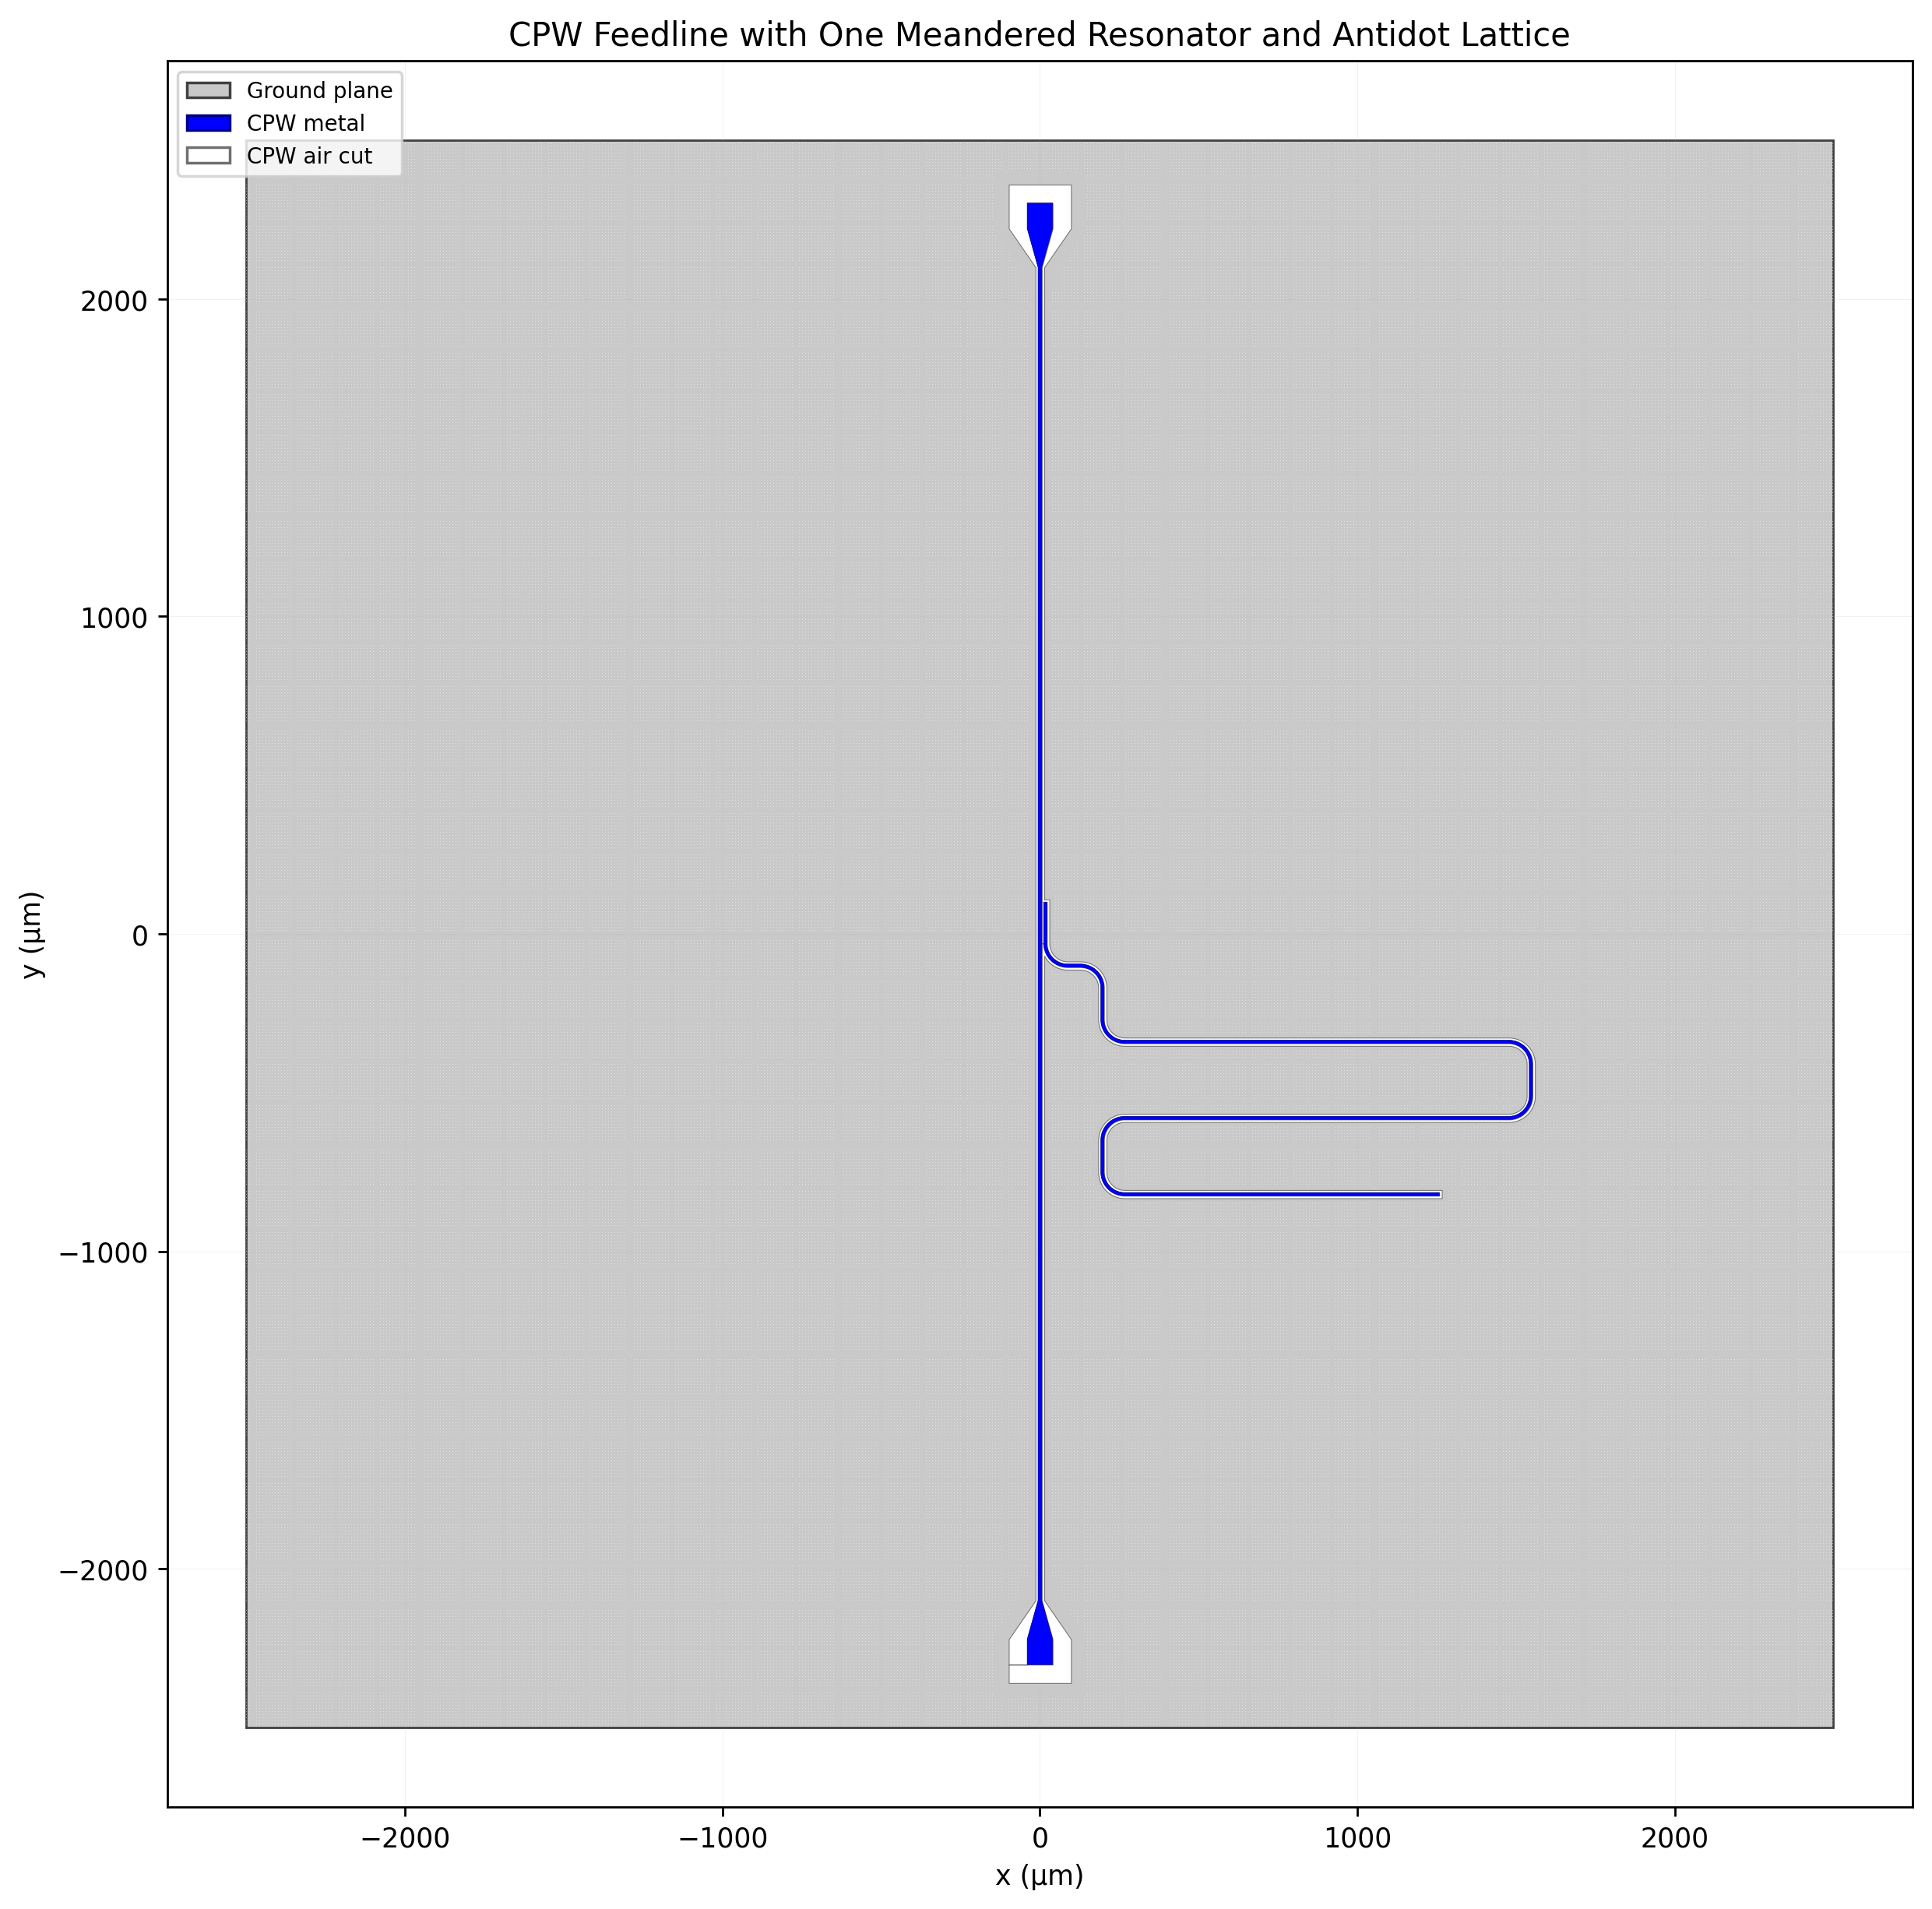

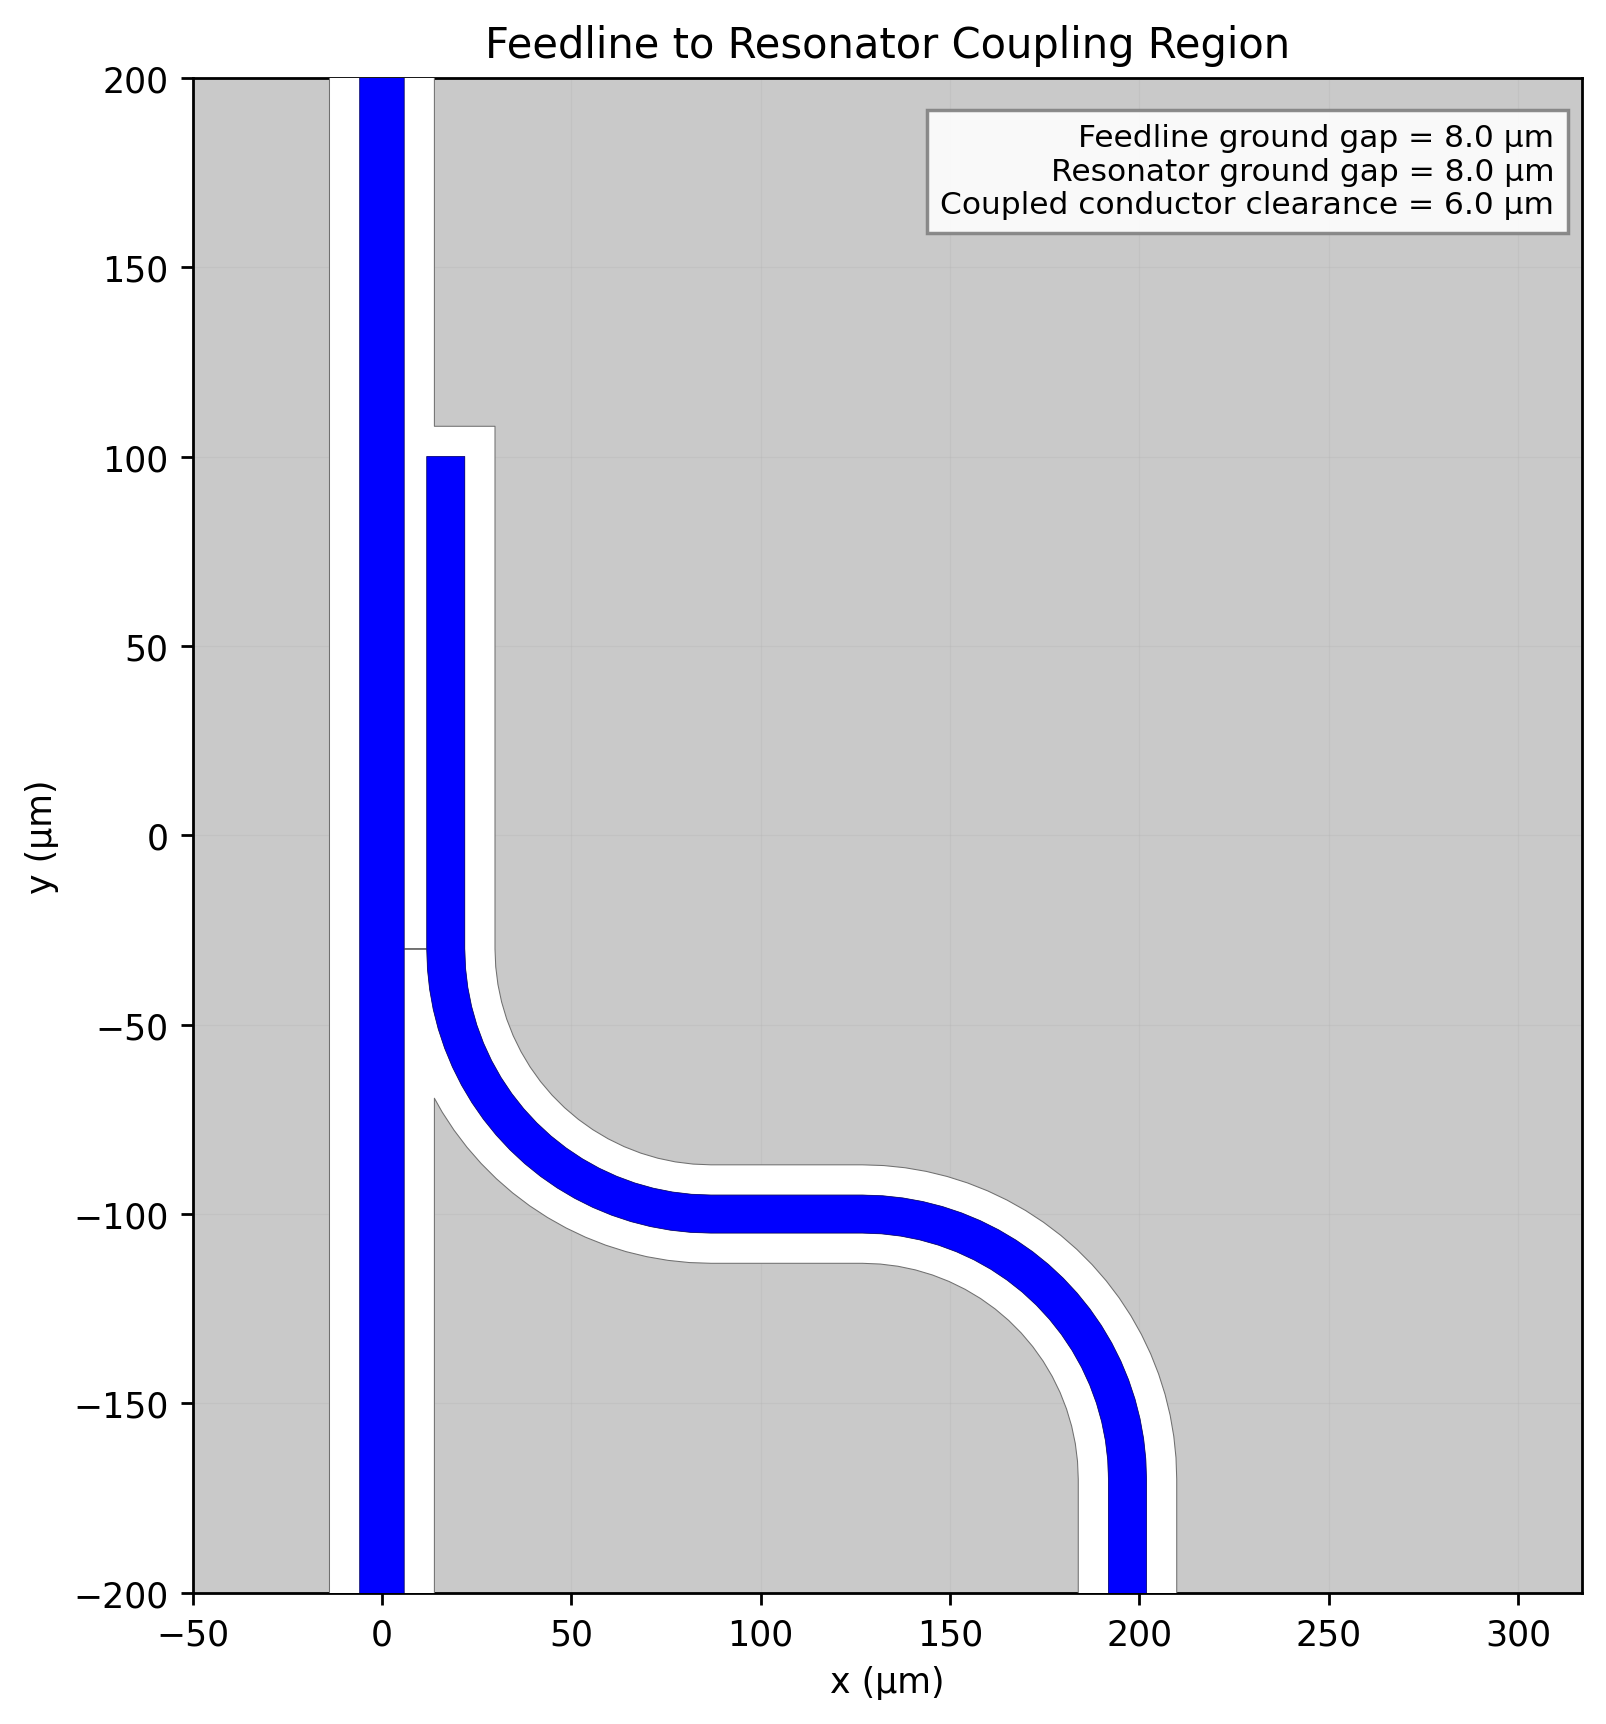

In [3]:
"""Build a PHIDL and GDSTK CPW feedline with one meandered resonator.

The layout contains Qiskit Metal LaunchpadWirebond style launchers,
explicit CPW air cuts, a filtered square antidot lattice, an in-memory
Matplotlib preview, and a verified GDSII output.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.patches import Rectangle
from phidl import Device


# -----------------------------------------------------------------------------
# CONTROL KNOBS
# -----------------------------------------------------------------------------

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/cpw_feedline_single_meander_antidots.gds"
)

WRITE_GDS: Final[bool] = True
VERIFY_GDS_AFTER_WRITE: Final[bool] = True
DOWNLOAD_GDS_AFTER_WRITE: Final[bool] = False

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 10.0
FIGURE_HEIGHT_IN: Final[float] = 10.0
RENDER_COUPLER_ZOOM: Final[bool] = True

CHIP_SIZE_X_UM: Final[float] = 5000.0
CHIP_SIZE_Y_UM: Final[float] = 5000.0

GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9
BOOLEAN_PRECISION_UM: Final[float] = 1.0e-3


# -----------------------------------------------------------------------------
# GDS LAYER MAP
# -----------------------------------------------------------------------------

METAL_LAYER: Final[int] = 3
METAL_DATATYPE: Final[int] = 0

AIR_CUT_LAYER: Final[int] = 3
AIR_CUT_DATATYPE: Final[int] = 1

METAL_SPEC: Final[tuple[int, int]] = (
    METAL_LAYER,
    METAL_DATATYPE,
)

FOOTPRINT_SPEC: Final[tuple[int, int]] = (
    AIR_CUT_LAYER,
    AIR_CUT_DATATYPE,
)


# -----------------------------------------------------------------------------
# FEEDLINE CPW
# -----------------------------------------------------------------------------

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7

# Enlarged from 5.1 µm so the air slots have better geometric clearance and
# are readily visible in a full-chip rendering.
FEEDLINE_TRACE_GAP_UM: Final[float] = 8.0


# -----------------------------------------------------------------------------
# QISKIT METAL LAUNCHPADWIREBOND GEOMETRY
# -----------------------------------------------------------------------------

LAUNCHER_CENTER_Y_UM: Final[float] = 2100.0

LAUNCHER_LEAD_LENGTH_UM: Final[float] = 25.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 80.0
LAUNCHER_PAD_HEIGHT_UM: Final[float] = 80.0
LAUNCHER_PAD_GAP_UM: Final[float] = 58.0
LAUNCHER_TAPER_HEIGHT_UM: Final[float] = 122.0

TOP_LAUNCHER_ORIENTATION_DEG: Final[float] = -90.0
BOTTOM_LAUNCHER_ORIENTATION_DEG: Final[float] = 90.0


# -----------------------------------------------------------------------------
# SINGLE MEANDERING CPW RESONATOR
# -----------------------------------------------------------------------------

RESONATOR_TRACE_WIDTH_UM: Final[float] = 10.0

# Enlarged from 6 µm for a clearer ground-plane slot.
RESONATOR_TRACE_GAP_UM: Final[float] = 8.0

# Conductor-edge clearance inside the coupled section.
RESONATOR_COUPLING_SPACE_UM: Final[float] = 6.0
RESONATOR_COUPLING_LENGTH_UM: Final[float] = 200.0

RESONATOR_FILLET_UM: Final[float] = 70.0

RESONATOR_LEAD_START_UM: Final[float] = 180.0
RESONATOR_MEANDER_PITCH_UM: Final[float] = 240.0
RESONATOR_MEANDER_SPAN_UM: Final[float] = 1350.0

RESONATOR_COUPLER_CENTER_Y_UM: Final[float] = 0.0

TARGET_RESONATOR_FREQUENCY_GHZ: Final[float] = 6.45
CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

# The open termination gets a complete air cap equal to the local CPW gap.
OPEN_END_GAP_EXTENSION_UM: Final[float] = RESONATOR_TRACE_GAP_UM


# -----------------------------------------------------------------------------
# FILLET CONTROLS
# -----------------------------------------------------------------------------

FILLET_SAFETY_FRACTION: Final[float] = 0.42
MIN_FILLET_RADIUS_UM: Final[float] = 8.0


# -----------------------------------------------------------------------------
# ANTIDOT LATTICE
# -----------------------------------------------------------------------------

ENABLE_ANTIDOTS: Final[bool] = True

ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0

ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0

ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

CLIP_ANTIDOTS_TO_CHIP: Final[bool] = True


# -----------------------------------------------------------------------------
# LIGHTWEIGHT DESIGN CHECKS
# -----------------------------------------------------------------------------

MIN_CPW_GAP_UM: Final[float] = 3.0
MIN_METAL_SPACING_UM: Final[float] = 2.0


# -----------------------------------------------------------------------------
# RENDERING CONTROLS
# -----------------------------------------------------------------------------

GROUND_FACE: Final[str] = "#C9C9C9"
CHIP_EDGE: Final[str] = "#404040"

METAL_FACE: Final[str] = "#0000FF"
METAL_EDGE: Final[str] = "#000080"

AIR_FACE: Final[str] = "#FFFFFF"
AIR_EDGE: Final[str] = "#707070"

ANTIDOT_FACE: Final[str] = "#FFFFFF"
ANTIDOT_ALPHA: Final[float] = 0.45

mpl.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI


# -----------------------------------------------------------------------------
# DATA STRUCTURES
# -----------------------------------------------------------------------------


@dataclass
class LayoutResult:
    """Store generated PHIDL and GDSTK layout information."""

    phidl_device: Device
    library: gdstk.Library
    top_cell: gdstk.Cell

    conductor_polygons: list[gdstk.Polygon]
    air_cut_polygons: list[gdstk.Polygon]

    ordinary_footprints: list[gdstk.Polygon]
    launcher_footprints: list[gdstk.Polygon]

    antidot_points: np.ndarray
    antidot_references: list[gdstk.Reference]

    resonator_points: np.ndarray

    resonator_target_length_um: float
    resonator_rounded_length_um: float
    resonator_fillet_um: float

    candidate_antidot_count: int

    gds_path: Path
    gds_size_bytes: int


# -----------------------------------------------------------------------------
# BASIC GEOMETRY HELPERS
# -----------------------------------------------------------------------------


def add_rectangle(
    device: Device,
    x0: float,
    y0: float,
    x1: float,
    y1: float,
    layer: tuple[int, int],
) -> None:
    """Add an axis-aligned rectangular polygon to a PHIDL device."""

    x_min = min(x0, x1)
    x_max = max(x0, x1)
    y_min = min(y0, y1)
    y_max = max(y0, y1)

    device.add_polygon(
        [
            (x_min, y_min),
            (x_max, y_min),
            (x_max, y_max),
            (x_min, y_max),
        ],
        layer=layer,
    )


def union_polygons(
    polygons: list[gdstk.Polygon],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Return the Boolean union of a polygon collection."""

    if len(polygons) == 0:
        return []

    return gdstk.boolean(
        polygons,
        [],
        "or",
        precision=BOOLEAN_PRECISION_UM,
        layer=layer,
        datatype=datatype,
    )


def phidl_polygons_to_gdstk(
    device: Device,
    spec: tuple[int, int],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert one PHIDL layer specification to GDSTK polygons."""

    polygons_by_spec = device.get_polygons(
        by_spec=True
    )

    polygon_arrays = polygons_by_spec.get(
        spec,
        [],
    )

    return [
        gdstk.Polygon(
            np.asarray(
                points,
                dtype=np.float64,
            ),
            layer=layer,
            datatype=datatype,
        )
        for points in polygon_arrays
    ]


# -----------------------------------------------------------------------------
# QISKIT METAL STYLE LAUNCHER
# -----------------------------------------------------------------------------


def create_launchpad_wirebond(
    name: str,
    pos_x_um: float,
    pos_y_um: float,
    orientation_deg: float,
) -> Device:
    """Create the supplied Qiskit Metal LaunchpadWirebond geometry."""

    device = Device(name)

    trace_half = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    pad_half = (
        LAUNCHER_PAD_WIDTH_UM
        / 2.0
    )

    lead_length = (
        LAUNCHER_LEAD_LENGTH_UM
    )

    taper_height = (
        LAUNCHER_TAPER_HEIGHT_UM
    )

    pad_height = (
        LAUNCHER_PAD_HEIGHT_UM
    )

    pad_gap = (
        LAUNCHER_PAD_GAP_UM
    )

    trace_gap = (
        FEEDLINE_TRACE_GAP_UM
    )

    # - Positive launch metal

    launch_pad = [
        (
            0.0,
            trace_half,
        ),
        (
            -taper_height,
            pad_half,
        ),
        (
            -(pad_height + taper_height),
            pad_half,
        ),
        (
            -(pad_height + taper_height),
            -pad_half,
        ),
        (
            -taper_height,
            -pad_half,
        ),
        (
            0.0,
            -trace_half,
        ),
        (
            lead_length,
            -trace_half,
        ),
        (
            lead_length,
            trace_half,
        ),
        (
            0.0,
            trace_half,
        ),
    ]

    # - Qiskit Metal ground pocket

    pocket = [
        (
            0.0,
            trace_half + trace_gap,
        ),
        (
            -taper_height,
            pad_half + pad_gap,
        ),
        (
            -(
                pad_height
                + taper_height
                + pad_gap
            ),
            pad_half + pad_gap,
        ),
        (
            -(
                pad_height
                + taper_height
                + pad_gap
            ),
            -(pad_half + pad_gap),
        ),
        (
            -taper_height,
            -(pad_half + pad_gap),
        ),
        (
            0.0,
            -(trace_half + trace_gap),
        ),
        (
            lead_length,
            -(trace_half + trace_gap),
        ),
        (
            lead_length,
            trace_half + trace_gap,
        ),
        (
            0.0,
            trace_half + trace_gap,
        ),
    ]

    device.add_polygon(
        launch_pad,
        layer=METAL_SPEC,
    )

    device.add_polygon(
        pocket,
        layer=FOOTPRINT_SPEC,
    )

    device.add_port(
        name="tie",
        midpoint=(
            lead_length,
            0.0,
        ),
        width=FEEDLINE_TRACE_WIDTH_UM,
        orientation=0.0,
    )

    device.rotate(
        angle=orientation_deg,
        center=(
            0.0,
            0.0,
        ),
    )

    device.move(
        origin=(
            0.0,
            0.0,
        ),
        destination=(
            pos_x_um,
            pos_y_um,
        ),
    )

    return device


# -----------------------------------------------------------------------------
# FEEDLINE
# -----------------------------------------------------------------------------


def create_feedline(
    top_launcher: Device,
    bottom_launcher: Device,
) -> Device:
    """Create the straight vertical CPW between both launcher tie pins."""

    device = Device(
        "feedline"
    )

    top_pin = np.asarray(
        top_launcher.ports[
            "tie"
        ].midpoint,
        dtype=np.float64,
    )

    bottom_pin = np.asarray(
        bottom_launcher.ports[
            "tie"
        ].midpoint,
        dtype=np.float64,
    )

    center_x = float(
        0.5
        * (
            top_pin[0]
            + bottom_pin[0]
        )
    )

    y_min = float(
        min(
            top_pin[1],
            bottom_pin[1],
        )
    )

    y_max = float(
        max(
            top_pin[1],
            bottom_pin[1],
        )
    )

    conductor_half = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    footprint_half = (
        conductor_half
        + FEEDLINE_TRACE_GAP_UM
    )

    add_rectangle(
        device=device,
        x0=center_x - conductor_half,
        y0=y_min,
        x1=center_x + conductor_half,
        y1=y_max,
        layer=METAL_SPEC,
    )

    add_rectangle(
        device=device,
        x0=center_x - footprint_half,
        y0=y_min,
        x1=center_x + footprint_half,
        y1=y_max,
        layer=FOOTPRINT_SPEC,
    )

    return device


# -----------------------------------------------------------------------------
# RESONATOR LENGTH MODEL
# -----------------------------------------------------------------------------


def quarter_wave_length_um(
    frequency_ghz: float,
) -> float:
    """Calculate a first-pass quarter-wave centerline length."""

    frequency_hz = (
        frequency_ghz
        * 1.0e9
    )

    return (
        CPW_PHASE_VELOCITY_M_PER_S
        / (
            4.0
            * frequency_hz
        )
        * 1.0e6
    )


def polyline_length_um(
    points: np.ndarray,
) -> float:
    """Calculate total piecewise-linear centerline length."""

    segment_vectors = np.diff(
        points,
        axis=0,
    )

    segment_lengths = np.linalg.norm(
        segment_vectors,
        axis=1,
    )

    return float(
        np.sum(
            segment_lengths
        )
    )


def safe_fillet_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the fillet radius to available neighboring segments."""

    if (
        points.shape[0] < 3
        or requested_radius_um <= 0.0
    ):
        return 0.0

    segment_lengths = np.linalg.norm(
        np.diff(
            points,
            axis=0,
        ),
        axis=1,
    )

    limits = [
        min(
            segment_lengths[index - 1],
            segment_lengths[index],
        )
        for index in range(
            1,
            points.shape[0] - 1,
        )
    ]

    if len(limits) == 0:
        return 0.0

    allowed_radius = (
        FILLET_SAFETY_FRACTION
        * min(limits)
    )

    radius = min(
        requested_radius_um,
        allowed_radius,
    )

    if (
        radius
        < MIN_FILLET_RADIUS_UM
    ):
        return 0.0

    return float(radius)


def rounded_centerline_length_um(
    points: np.ndarray,
    radius_um: float,
) -> float:
    """Estimate centerline length after circular corner replacement."""

    total_length = (
        polyline_length_um(
            points
        )
    )

    if radius_um <= 0.0:
        return total_length

    length_reduction = 0.0

    for index in range(
        1,
        points.shape[0] - 1,
    ):
        incoming = (
            points[index]
            - points[index - 1]
        )

        outgoing = (
            points[index + 1]
            - points[index]
        )

        incoming_length = float(
            np.linalg.norm(
                incoming
            )
        )

        outgoing_length = float(
            np.linalg.norm(
                outgoing
            )
        )

        if (
            incoming_length <= 1.0e-12
            or outgoing_length <= 1.0e-12
        ):
            continue

        incoming_unit = (
            incoming
            / incoming_length
        )

        outgoing_unit = (
            outgoing
            / outgoing_length
        )

        cosine_angle = float(
            np.clip(
                np.dot(
                    incoming_unit,
                    outgoing_unit,
                ),
                -1.0,
                1.0,
            )
        )

        angle_rad = float(
            np.arccos(
                cosine_angle
            )
        )

        if (
            angle_rad <= 1.0e-12
            or abs(
                np.pi
                - angle_rad
            )
            <= 1.0e-12
        ):
            continue

        trim_um = (
            radius_um
            * np.tan(
                0.5
                * angle_rad
            )
        )

        arc_length_um = (
            radius_um
            * angle_rad
        )

        length_reduction += (
            2.0
            * trim_um
            - arc_length_um
        )

    return (
        total_length
        - length_reduction
    )


def resonator_coupling_x_um() -> float:
    """Return resonator center x for the requested conductor clearance."""

    feedline_edge = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    resonator_half = (
        RESONATOR_TRACE_WIDTH_UM
        / 2.0
    )

    return (
        feedline_edge
        + RESONATOR_COUPLING_SPACE_UM
        + resonator_half
    )


def build_meander_centerline(
    target_polyline_length_um: float,
) -> np.ndarray:
    """Create a compact single-resonator Manhattan centerline."""

    coupling_x = (
        resonator_coupling_x_um()
    )

    coupling_half_length = (
        RESONATOR_COUPLING_LENGTH_UM
        / 2.0
    )

    y_top = (
        RESONATOR_COUPLER_CENTER_Y_UM
        + coupling_half_length
    )

    y_bottom = (
        RESONATOR_COUPLER_CENTER_Y_UM
        - coupling_half_length
    )

    points: list[list[float]] = [
        [
            coupling_x,
            y_top,
        ],
        [
            coupling_x,
            y_bottom,
        ],
        [
            coupling_x
            + RESONATOR_LEAD_START_UM,
            y_bottom,
        ],
    ]

    initial_points = np.asarray(
        points,
        dtype=np.float64,
    )

    remaining_length = (
        target_polyline_length_um
        - polyline_length_um(
            initial_points
        )
    )

    if remaining_length <= 0.0:
        raise ValueError(
            "Target resonator length is too short for the coupling section."
        )

    current_x = float(
        points[-1][0]
    )

    current_y = float(
        points[-1][1]
    )

    horizontal_direction = 1.0

    for _ in range(32):
        if remaining_length <= 1.0e-9:
            break

        vertical_length = min(
            RESONATOR_MEANDER_PITCH_UM,
            remaining_length,
        )

        current_y -= (
            vertical_length
        )

        points.append(
            [
                current_x,
                current_y,
            ]
        )

        remaining_length -= (
            vertical_length
        )

        if remaining_length <= 1.0e-9:
            break

        horizontal_length = min(
            RESONATOR_MEANDER_SPAN_UM,
            remaining_length,
        )

        current_x += (
            horizontal_direction
            * horizontal_length
        )

        points.append(
            [
                current_x,
                current_y,
            ]
        )

        remaining_length -= (
            horizontal_length
        )

        if (
            horizontal_length
            >= RESONATOR_MEANDER_SPAN_UM
            - 1.0e-9
        ):
            horizontal_direction *= -1.0

    if remaining_length > 1.0e-6:
        raise RuntimeError(
            "Meander bounds are too small for the requested resonator length."
        )

    return np.asarray(
        points,
        dtype=np.float64,
    )


def design_resonator_centerline(
) -> tuple[
    np.ndarray,
    float,
    float,
    float,
]:
    """Adjust Manhattan length to compensate for circular fillets."""

    target_length_um = (
        quarter_wave_length_um(
            TARGET_RESONATOR_FREQUENCY_GHZ
        )
    )

    requested_polyline_length_um = (
        target_length_um
    )

    points = (
        build_meander_centerline(
            requested_polyline_length_um
        )
    )

    fillet_um = (
        safe_fillet_radius_um(
            points,
            RESONATOR_FILLET_UM,
        )
    )

    rounded_length_um = (
        rounded_centerline_length_um(
            points,
            fillet_um,
        )
    )

    for _ in range(10):
        error_um = (
            target_length_um
            - rounded_length_um
        )

        if abs(error_um) <= 0.01:
            break

        requested_polyline_length_um += (
            error_um
        )

        points = (
            build_meander_centerline(
                requested_polyline_length_um
            )
        )

        fillet_um = (
            safe_fillet_radius_um(
                points,
                RESONATOR_FILLET_UM,
            )
        )

        rounded_length_um = (
            rounded_centerline_length_um(
                points,
                fillet_um,
            )
        )

    return (
        points,
        fillet_um,
        target_length_um,
        rounded_length_um,
    )


# -----------------------------------------------------------------------------
# RESONATOR GDSTK GEOMETRY
# -----------------------------------------------------------------------------


def create_flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    fillet_um: float,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Create filleted polygon geometry from a GDSTK FlexPath."""

    path = gdstk.FlexPath(
        points,
        width_um,
        joins="round",
        ends="flush",
        bend_radius=fillet_um,
        tolerance=0.05,
        layer=layer,
        datatype=datatype,
    )

    return path.to_polygons()


def create_open_end_footprint_extension(
    endpoint: np.ndarray,
    outward_vector: np.ndarray,
    outer_width_um: float,
) -> list[gdstk.Polygon]:
    """Extend the CPW footprint beyond an electrically open conductor end."""

    magnitude = float(
        np.linalg.norm(
            outward_vector
        )
    )

    if magnitude <= 1.0e-12:
        return []

    direction = (
        outward_vector
        / magnitude
    )

    extended_endpoint = (
        endpoint
        + direction
        * OPEN_END_GAP_EXTENSION_UM
    )

    extension = gdstk.FlexPath(
        [
            endpoint,
            extended_endpoint,
        ],
        outer_width_um,
        ends="flush",
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )

    return extension.to_polygons()


def create_resonator_geometry(
) -> tuple[
    np.ndarray,
    list[gdstk.Polygon],
    list[gdstk.Polygon],
    float,
    float,
    float,
]:
    """Create resonator conductor and full CPW footprint polygons."""

    (
        points,
        fillet_um,
        target_length_um,
        rounded_length_um,
    ) = design_resonator_centerline()

    conductor = (
        create_flexpath_polygons(
            points=points,
            width_um=RESONATOR_TRACE_WIDTH_UM,
            fillet_um=fillet_um,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
    )

    outer_width_um = (
        RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )

    footprint = (
        create_flexpath_polygons(
            points=points,
            width_um=outer_width_um,
            fillet_um=fillet_um,
            layer=AIR_CUT_LAYER,
            datatype=AIR_CUT_DATATYPE,
        )
    )

    footprint.extend(
        create_open_end_footprint_extension(
            endpoint=points[0],
            outward_vector=(
                points[0]
                - points[1]
            ),
            outer_width_um=outer_width_um,
        )
    )

    footprint.extend(
        create_open_end_footprint_extension(
            endpoint=points[-1],
            outward_vector=(
                points[-1]
                - points[-2]
            ),
            outer_width_um=outer_width_um,
        )
    )

    return (
        points,
        conductor,
        footprint,
        fillet_um,
        target_length_um,
        rounded_length_um,
    )


# -----------------------------------------------------------------------------
# TRUE CPW AIR CUTS
# -----------------------------------------------------------------------------


def create_air_cut_polygons(
    footprint_polygons: list[gdstk.Polygon],
    conductor_polygons: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Calculate physical air slots as outer footprint minus conductor metal."""

    footprints = union_polygons(
        footprint_polygons,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )

    conductors = union_polygons(
        conductor_polygons,
        METAL_LAYER,
        METAL_DATATYPE,
    )

    if len(footprints) == 0:
        return []

    if len(conductors) == 0:
        return footprints

    return gdstk.boolean(
        footprints,
        conductors,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )


# -----------------------------------------------------------------------------
# ANTIDOT GEOMETRY
# -----------------------------------------------------------------------------


def create_antidot_keepout(
    ordinary_footprints: list[gdstk.Polygon],
    launcher_footprints: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Expand CPW footprints so antidot squares stay clear of microwave cuts."""

    antidot_half = (
        ANTIDOT_SIZE_UM
        / 2.0
    )

    keepout_polygons: list[gdstk.Polygon] = []

    if len(ordinary_footprints) > 0:
        keepout_polygons.extend(
            gdstk.offset(
                ordinary_footprints,
                ANTIDOT_KEEPOUT_UM
                + antidot_half,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )

    if len(launcher_footprints) > 0:
        keepout_polygons.extend(
            gdstk.offset(
                launcher_footprints,
                LAUNCHPAD_KEEPOUT_UM
                + antidot_half,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )

    return keepout_polygons


def build_antidot_grid(
    keepout_polygons: list[gdstk.Polygon],
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    int,
]:
    """Generate and filter the square antidot lattice."""

    if ENABLE_ANTIDOTS is False:
        return (
            np.empty(
                0,
                dtype=np.float64,
            ),
            np.empty(
                0,
                dtype=np.float64,
            ),
            np.empty(
                (
                    0,
                    0,
                ),
                dtype=bool,
            ),
            0,
        )

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    x_positive = np.arange(
        ANTIDOT_OFFSET_X_UM,
        chip_half_x,
        ANTIDOT_PITCH_UM,
        dtype=np.float64,
    )

    x_coordinates = np.unique(
        np.concatenate(
            (
                -x_positive,
                x_positive,
            )
        )
    )

    y_limit = (
        chip_half_y
        + ANTIDOT_EXTENSION_Y_UM
    )

    y_positive = np.arange(
        ANTIDOT_OFFSET_Y_UM,
        y_limit,
        ANTIDOT_PITCH_UM,
        dtype=np.float64,
    )

    y_coordinates = np.unique(
        np.concatenate(
            (
                -y_positive,
                y_positive,
            )
        )
    )

    x_mesh, y_mesh = np.meshgrid(
        x_coordinates,
        y_coordinates,
        indexing="xy",
    )

    candidates = np.column_stack(
        (
            x_mesh.ravel(),
            y_mesh.ravel(),
        )
    )

    candidate_count = int(
        candidates.shape[0]
    )

    if len(keepout_polygons) > 0:
        inside_keepout = np.asarray(
            gdstk.inside(
                candidates,
                keepout_polygons,
            ),
            dtype=bool,
        )

    else:
        inside_keepout = np.zeros(
            candidate_count,
            dtype=bool,
        )

    keep = (
        ~inside_keepout
    )

    if CLIP_ANTIDOTS_TO_CHIP:
        antidot_half = (
            ANTIDOT_SIZE_UM
            / 2.0
        )

        inside_chip = (
            (
                np.abs(
                    candidates[:, 0]
                )
                <= (
                    chip_half_x
                    - antidot_half
                )
            )
            & (
                np.abs(
                    candidates[:, 1]
                )
                <= (
                    chip_half_y
                    - antidot_half
                )
            )
        )

        keep &= inside_chip

    keep_mask = keep.reshape(
        y_coordinates.size,
        x_coordinates.size,
    )

    return (
        x_coordinates,
        y_coordinates,
        keep_mask,
        candidate_count,
    )


def create_antidot_references(
    antidot_cell: gdstk.Cell,
    x_coordinates: np.ndarray,
    y_coordinates: np.ndarray,
    keep_mask: np.ndarray,
) -> list[gdstk.Reference]:
    """Compress retained antidots into contiguous horizontal GDS arrays."""

    references: list[gdstk.Reference] = []

    if keep_mask.size == 0:
        return references

    for row_index, y_coordinate in enumerate(
        y_coordinates
    ):
        indices = np.flatnonzero(
            keep_mask[
                row_index
            ]
        )

        if indices.size == 0:
            continue

        if indices.size == 1:
            groups = [
                indices
            ]

        else:
            index_break = (
                np.diff(
                    indices
                )
                != 1
            )

            physical_break = (
                np.abs(
                    np.diff(
                        x_coordinates[
                            indices
                        ]
                    )
                    - ANTIDOT_PITCH_UM
                )
                > 1.0e-9
            )

            split_locations = (
                np.flatnonzero(
                    index_break
                    | physical_break
                )
                + 1
            )

            groups = np.split(
                indices,
                split_locations,
            )

        for group in groups:
            if group.size == 0:
                continue

            origin = (
                float(
                    x_coordinates[
                        group[0]
                    ]
                ),
                float(
                    y_coordinate
                ),
            )

            if group.size == 1:
                references.append(
                    gdstk.Reference(
                        antidot_cell,
                        origin=origin,
                    )
                )

            else:
                references.append(
                    gdstk.Reference(
                        antidot_cell,
                        origin=origin,
                        columns=int(
                            group.size
                        ),
                        rows=1,
                        spacing=(
                            ANTIDOT_PITCH_UM,
                            ANTIDOT_PITCH_UM,
                        ),
                    )
                )

    return references


# -----------------------------------------------------------------------------
# DESIGN AUDITS
# -----------------------------------------------------------------------------


def validate_control_knobs() -> None:
    """Check critical dimensional controls before geometry generation."""

    if (
        FEEDLINE_TRACE_GAP_UM
        < MIN_CPW_GAP_UM
    ):
        raise ValueError(
            "Feedline CPW gap is below the configured minimum."
        )

    if (
        RESONATOR_TRACE_GAP_UM
        < MIN_CPW_GAP_UM
    ):
        raise ValueError(
            "Resonator CPW gap is below the configured minimum."
        )

    if (
        RESONATOR_COUPLING_SPACE_UM
        < MIN_METAL_SPACING_UM
    ):
        raise ValueError(
            "Coupling clearance is below the configured metal-spacing minimum."
        )

    if (
        ANTIDOT_SIZE_UM
        >= ANTIDOT_PITCH_UM
    ):
        raise ValueError(
            "Antidot size must be smaller than the antidot pitch."
        )


def air_metal_intersection_area_um2(
    air_polygons: list[gdstk.Polygon],
    metal_polygons: list[gdstk.Polygon],
) -> float:
    """Calculate residual overlap between final air cuts and conductor metal."""

    intersections = gdstk.boolean(
        air_polygons,
        metal_polygons,
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )

    return float(
        sum(
            abs(
                polygon.area()
            )
            for polygon in intersections
        )
    )


# -----------------------------------------------------------------------------
# GDS WRITE AND VERIFICATION
# -----------------------------------------------------------------------------


def write_and_verify_gds(
    library: gdstk.Library,
    output_path: Path,
) -> int:
    """Write the GDS file and verify that GDSTK can reopen it."""

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    library.write_gds(
        str(
            output_path
        )
    )

    if output_path.exists() is False:
        raise RuntimeError(
            f"GDS output was not created at {output_path}."
        )

    file_size = int(
        output_path.stat().st_size
    )

    if file_size <= 0:
        raise RuntimeError(
            "The generated GDS file is empty."
        )

    if VERIFY_GDS_AFTER_WRITE:
        reloaded_library = (
            gdstk.read_gds(
                str(
                    output_path
                )
            )
        )

        top_cells = (
            reloaded_library.top_level()
        )

        if len(top_cells) == 0:
            raise RuntimeError(
                "The written GDS contains no top-level cell."
            )

    return file_size


# -----------------------------------------------------------------------------
# COMPLETE BUILD
# -----------------------------------------------------------------------------


def build_layout() -> LayoutResult:
    """Build the complete launcher, feedline, resonator, antidot, and GDS layout."""

    validate_control_knobs()

    # - Launchers

    top_launcher = (
        create_launchpad_wirebond(
            name="launcher_top",
            pos_x_um=0.0,
            pos_y_um=LAUNCHER_CENTER_Y_UM,
            orientation_deg=TOP_LAUNCHER_ORIENTATION_DEG,
        )
    )

    bottom_launcher = (
        create_launchpad_wirebond(
            name="launcher_bottom",
            pos_x_um=0.0,
            pos_y_um=-LAUNCHER_CENTER_Y_UM,
            orientation_deg=BOTTOM_LAUNCHER_ORIENTATION_DEG,
        )
    )

    # - Feedline

    feedline = (
        create_feedline(
            top_launcher,
            bottom_launcher,
        )
    )

    # - PHIDL hierarchy

    phidl_device = Device(
        "CPW_FEEDLINE_SINGLE_MEANDER"
    )

    phidl_device.add_ref(
        top_launcher
    )

    phidl_device.add_ref(
        bottom_launcher
    )

    phidl_device.add_ref(
        feedline
    )

    # - Launcher conversion

    launcher_metal = (
        phidl_polygons_to_gdstk(
            top_launcher,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
        + phidl_polygons_to_gdstk(
            bottom_launcher,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    launcher_footprints = (
        phidl_polygons_to_gdstk(
            top_launcher,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
        + phidl_polygons_to_gdstk(
            bottom_launcher,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    # - Feedline conversion

    feedline_metal = (
        phidl_polygons_to_gdstk(
            feedline,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    feedline_footprints = (
        phidl_polygons_to_gdstk(
            feedline,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    # - Meandered resonator

    (
        resonator_points,
        resonator_metal,
        resonator_footprints,
        fillet_um,
        target_length_um,
        rounded_length_um,
    ) = create_resonator_geometry()

    # - Positive conductor union

    conductor_polygons = (
        union_polygons(
            launcher_metal
            + feedline_metal
            + resonator_metal,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    # - Footprints used to construct physical air slots

    ordinary_footprints = (
        union_polygons(
            feedline_footprints
            + resonator_footprints,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    launcher_footprints = (
        union_polygons(
            launcher_footprints,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    all_footprints = (
        ordinary_footprints
        + launcher_footprints
    )

    # - Actual CPW air cuts

    air_cut_polygons = (
        create_air_cut_polygons(
            footprint_polygons=all_footprints,
            conductor_polygons=conductor_polygons,
        )
    )

    # - Antidot lattice

    keepout_polygons = (
        create_antidot_keepout(
            ordinary_footprints=ordinary_footprints,
            launcher_footprints=launcher_footprints,
        )
    )

    (
        x_coordinates,
        y_coordinates,
        antidot_mask,
        candidate_antidot_count,
    ) = build_antidot_grid(
        keepout_polygons
    )

    if antidot_mask.size > 0:
        x_mesh, y_mesh = np.meshgrid(
            x_coordinates,
            y_coordinates,
            indexing="xy",
        )

        all_antidot_points = (
            np.column_stack(
                (
                    x_mesh.ravel(),
                    y_mesh.ravel(),
                )
            )
        )

        antidot_points = (
            all_antidot_points[
                antidot_mask.ravel()
            ]
        )

    else:
        antidot_points = np.empty(
            (
                0,
                2,
            ),
            dtype=np.float64,
        )

    # - GDSTK hierarchy

    library = gdstk.Library(
        name="CPW_SINGLE_MEANDER",
        unit=GDS_UNIT_M,
        precision=GDS_PRECISION_M,
    )

    top_cell = (
        library.new_cell(
            "TOP"
        )
    )

    antidot_cell = (
        library.new_cell(
            "ANTIDOT"
        )
    )

    antidot_half = (
        ANTIDOT_SIZE_UM
        / 2.0
    )

    antidot_cell.add(
        gdstk.rectangle(
            (
                -antidot_half,
                -antidot_half,
            ),
            (
                antidot_half,
                antidot_half,
            ),
            layer=AIR_CUT_LAYER,
            datatype=AIR_CUT_DATATYPE,
        )
    )

    if len(conductor_polygons) > 0:
        top_cell.add(
            *conductor_polygons
        )

    if len(air_cut_polygons) > 0:
        top_cell.add(
            *air_cut_polygons
        )

    antidot_references = (
        create_antidot_references(
            antidot_cell=antidot_cell,
            x_coordinates=x_coordinates,
            y_coordinates=y_coordinates,
            keep_mask=antidot_mask,
        )
    )

    if len(antidot_references) > 0:
        top_cell.add(
            *antidot_references
        )

    # - Always create the requested GDS file

    gds_size_bytes = 0

    if WRITE_GDS:
        gds_size_bytes = (
            write_and_verify_gds(
                library=library,
                output_path=OUTPUT_GDS_PATH,
            )
        )

    return LayoutResult(
        phidl_device=phidl_device,
        library=library,
        top_cell=top_cell,
        conductor_polygons=conductor_polygons,
        air_cut_polygons=air_cut_polygons,
        ordinary_footprints=ordinary_footprints,
        launcher_footprints=launcher_footprints,
        antidot_points=antidot_points,
        antidot_references=antidot_references,
        resonator_points=resonator_points,
        resonator_target_length_um=target_length_um,
        resonator_rounded_length_um=rounded_length_um,
        resonator_fillet_um=fillet_um,
        candidate_antidot_count=candidate_antidot_count,
        gds_path=OUTPUT_GDS_PATH,
        gds_size_bytes=gds_size_bytes,
    )


# -----------------------------------------------------------------------------
# MATPLOTLIB RENDERING
# -----------------------------------------------------------------------------


def add_polygon_collection(
    axes: plt.Axes,
    polygons: list[gdstk.Polygon],
    facecolor: str,
    edgecolor: str,
    linewidth: float,
    zorder: float,
) -> None:
    """Render GDSTK polygons using one Matplotlib collection."""

    if len(polygons) == 0:
        return

    patches = [
        MplPolygon(
            np.asarray(
                polygon.points
            ),
            closed=True,
        )
        for polygon in polygons
    ]

    collection = PatchCollection(
        patches,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=zorder,
    )

    axes.add_collection(
        collection
    )


def render_geometry(
    axes: plt.Axes,
    result: LayoutResult,
    include_antidots: bool,
) -> None:
    """Render common ground, air, antidot, and conductor geometry."""

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    axes.add_patch(
        Rectangle(
            (
                -chip_half_x,
                -chip_half_y,
            ),
            CHIP_SIZE_X_UM,
            CHIP_SIZE_Y_UM,
            facecolor=GROUND_FACE,
            edgecolor=CHIP_EDGE,
            linewidth=0.8,
            zorder=0,
        )
    )

    if (
        include_antidots
        and result.antidot_points.shape[0] > 0
    ):
        plotted_span_um = (
            CHIP_SIZE_X_UM
            * 1.10
        )

        marker_side_points = (
            ANTIDOT_SIZE_UM
            / plotted_span_um
            * FIGURE_WIDTH_IN
            * 72.0
        )

        axes.scatter(
            result.antidot_points[:, 0],
            result.antidot_points[:, 1],
            s=marker_side_points**2,
            marker="s",
            facecolors=ANTIDOT_FACE,
            edgecolors="none",
            linewidths=0.0,
            alpha=ANTIDOT_ALPHA,
            rasterized=True,
            zorder=1,
        )

    # Air slots are deliberately opaque and outlined so the CPW geometry
    # remains visible over the dense antidot field.

    add_polygon_collection(
        axes=axes,
        polygons=result.air_cut_polygons,
        facecolor=AIR_FACE,
        edgecolor=AIR_EDGE,
        linewidth=0.30,
        zorder=3,
    )

    add_polygon_collection(
        axes=axes,
        polygons=result.conductor_polygons,
        facecolor=METAL_FACE,
        edgecolor=METAL_EDGE,
        linewidth=0.18,
        zorder=4,
    )


def render_full_layout(
    result: LayoutResult,
) -> None:
    """Render the entire chip in memory."""

    figure, axes = plt.subplots(
        figsize=(
            FIGURE_WIDTH_IN,
            FIGURE_HEIGHT_IN,
        )
    )

    render_geometry(
        axes,
        result,
        include_antidots=True,
    )

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    margin_um = (
        0.05
        * max(
            CHIP_SIZE_X_UM,
            CHIP_SIZE_Y_UM,
        )
    )

    axes.set_xlim(
        -chip_half_x - margin_um,
        chip_half_x + margin_um,
    )

    axes.set_ylim(
        -chip_half_y - margin_um,
        chip_half_y + margin_um,
    )

    axes.set_aspect(
        "equal",
        adjustable="box",
    )

    axes.set_xlabel(
        "x (µm)"
    )

    axes.set_ylabel(
        "y (µm)"
    )

    axes.set_title(
        "CPW Feedline with One Meandered Resonator and Antidot Lattice"
    )

    axes.grid(
        True,
        linewidth=0.25,
        alpha=0.20,
    )

    axes.legend(
        handles=[
            Patch(
                facecolor=GROUND_FACE,
                edgecolor=CHIP_EDGE,
                label="Ground plane",
            ),
            Patch(
                facecolor=METAL_FACE,
                edgecolor=METAL_EDGE,
                label="CPW metal",
            ),
            Patch(
                facecolor=AIR_FACE,
                edgecolor=AIR_EDGE,
                label="CPW air cut",
            ),
        ],
        loc="upper left",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()


def render_coupler_gap_zoom(
    result: LayoutResult,
) -> None:
    """Render a separate close view where individual CPW slots are resolvable."""

    if RENDER_COUPLER_ZOOM is False:
        return

    figure, axes = plt.subplots(
        figsize=(
            9.0,
            7.0,
        )
    )

    render_geometry(
        axes,
        result,
        include_antidots=False,
    )

    coupling_x = (
        resonator_coupling_x_um()
    )

    x_min = -50.0

    x_max = (
        coupling_x
        + RESONATOR_LEAD_START_UM
        + 120.0
    )

    y_half_span = (
        RESONATOR_COUPLING_LENGTH_UM
        / 2.0
        + 100.0
    )

    axes.set_xlim(
        x_min,
        x_max,
    )

    axes.set_ylim(
        -y_half_span,
        y_half_span,
    )

    axes.set_aspect(
        "equal",
        adjustable="box",
    )

    axes.set_xlabel(
        "x (µm)"
    )

    axes.set_ylabel(
        "y (µm)"
    )

    axes.set_title(
        "Feedline to Resonator Coupling Region"
    )

    axes.grid(
        True,
        linewidth=0.35,
        alpha=0.25,
    )

    gap_text = (
        f"Feedline ground gap = {FEEDLINE_TRACE_GAP_UM:.1f} µm\n"
        f"Resonator ground gap = {RESONATOR_TRACE_GAP_UM:.1f} µm\n"
        f"Coupled conductor clearance = "
        f"{RESONATOR_COUPLING_SPACE_UM:.1f} µm"
    )

    axes.text(
        0.98,
        0.97,
        gap_text,
        transform=axes.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9,
        },
    )

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# SUMMARY
# -----------------------------------------------------------------------------


def print_summary(
    result: LayoutResult,
) -> None:
    """Print layout dimensions, audits, and GDS output information."""

    retained_antidots = int(
        result.antidot_points.shape[0]
    )

    rejected_antidots = (
        result.candidate_antidot_count
        - retained_antidots
    )

    overlap_area_um2 = (
        air_metal_intersection_area_um2(
            result.air_cut_polygons,
            result.conductor_polygons,
        )
    )

    print(
        "PHIDL + GDSTK layout generated successfully."
    )

    print(
        "\nCPW air-gap geometry"
    )

    print(
        f"  Feedline trace width       : "
        f"{FEEDLINE_TRACE_WIDTH_UM:.2f} µm"
    )

    print(
        f"  Feedline ground gap        : "
        f"{FEEDLINE_TRACE_GAP_UM:.2f} µm per side"
    )

    print(
        f"  Resonator trace width      : "
        f"{RESONATOR_TRACE_WIDTH_UM:.2f} µm"
    )

    print(
        f"  Resonator ground gap       : "
        f"{RESONATOR_TRACE_GAP_UM:.2f} µm per side"
    )

    print(
        f"  Coupled conductor clearance: "
        f"{RESONATOR_COUPLING_SPACE_UM:.2f} µm"
    )

    print(
        f"  Open-end gap extension     : "
        f"{OPEN_END_GAP_EXTENSION_UM:.2f} µm"
    )

    print(
        "\nResonator"
    )

    print(
        f"  Target frequency           : "
        f"{TARGET_RESONATOR_FREQUENCY_GHZ:.3f} GHz"
    )

    print(
        f"  Target quarter-wave length : "
        f"{result.resonator_target_length_um:.2f} µm"
    )

    print(
        f"  Filleted centerline length : "
        f"{result.resonator_rounded_length_um:.2f} µm"
    )

    print(
        f"  Fillet radius              : "
        f"{result.resonator_fillet_um:.2f} µm"
    )

    print(
        "\nGeometry audit"
    )

    print(
        f"  Air-cut / metal overlap    : "
        f"{overlap_area_um2:.6e} µm²"
    )

    print(
        "\nAntidot lattice"
    )

    print(
        f"  Retained antidots          : "
        f"{retained_antidots:,}"
    )

    print(
        f"  Filtered antidots          : "
        f"{rejected_antidots:,}"
    )

    print(
        f"  GDS antidot arrays         : "
        f"{len(result.antidot_references):,}"
    )

    if WRITE_GDS:
        print(
            "\nGDS output"
        )

        print(
            f"  Path                       : "
            f"{result.gds_path}"
        )

        print(
            f"  File size                  : "
            f"{result.gds_size_bytes / 1024.0:.2f} KiB"
        )

        print(
            f"  Metal specification        : "
            f"L{METAL_LAYER} D{METAL_DATATYPE}"
        )

        print(
            f"  Air-cut specification      : "
            f"L{AIR_CUT_LAYER} D{AIR_CUT_DATATYPE}"
        )


# -----------------------------------------------------------------------------
# MAIN EXECUTION
# -----------------------------------------------------------------------------


def main() -> LayoutResult:
    """Build, write, verify, summarize, and render the complete layout."""

    result = build_layout()

    print_summary(
        result
    )

    render_full_layout(
        result
    )

    render_coupler_gap_zoom(
        result
    )

    if (
        WRITE_GDS
        and DOWNLOAD_GDS_AFTER_WRITE
    ):
        from google.colab import files

        files.download(
            str(
                result.gds_path
            )
        )

    return result


layout_result = main()

Adaptive GPU electromagnetic solver
  GPU                         : Tesla T4
  Free / total VRAM           : 14.22 / 14.56 GiB
  Detected regime             : planar quasi-TEM, severe multiscale separation
  Selected backend            : graph_tem_gpu
  Target frequency            : 6.450000 GHz
  Quarter-wave estimate       : 6.450000 GHz
  Adjacency eigenfrequency    : 6.424665 GHz
  Guided wavelength           : 18.605 mm
  Minimum layout feature      : 6.000 µm
  Scale-separation ratio      : 3,101 : 1

Explicit full-volume Yee estimate
  Nominal cell size           : 2.000 µm
  Approximate cell count      : 562,500,000
  Timesteps per RF cycle      : 42,371

Selected graph-FDTD discretization
  Graph nodes                 : 128
  Longitudinal spacing        : 36.623 µm
  Timesteps per RF cycle      : 552.2
  Discovery timesteps         : 23,192
  Driven-mode timesteps       : 16,566
  Loaded-Q model              : 125.8

GPU sparse / transverse solve
  Sparse matrix mode          

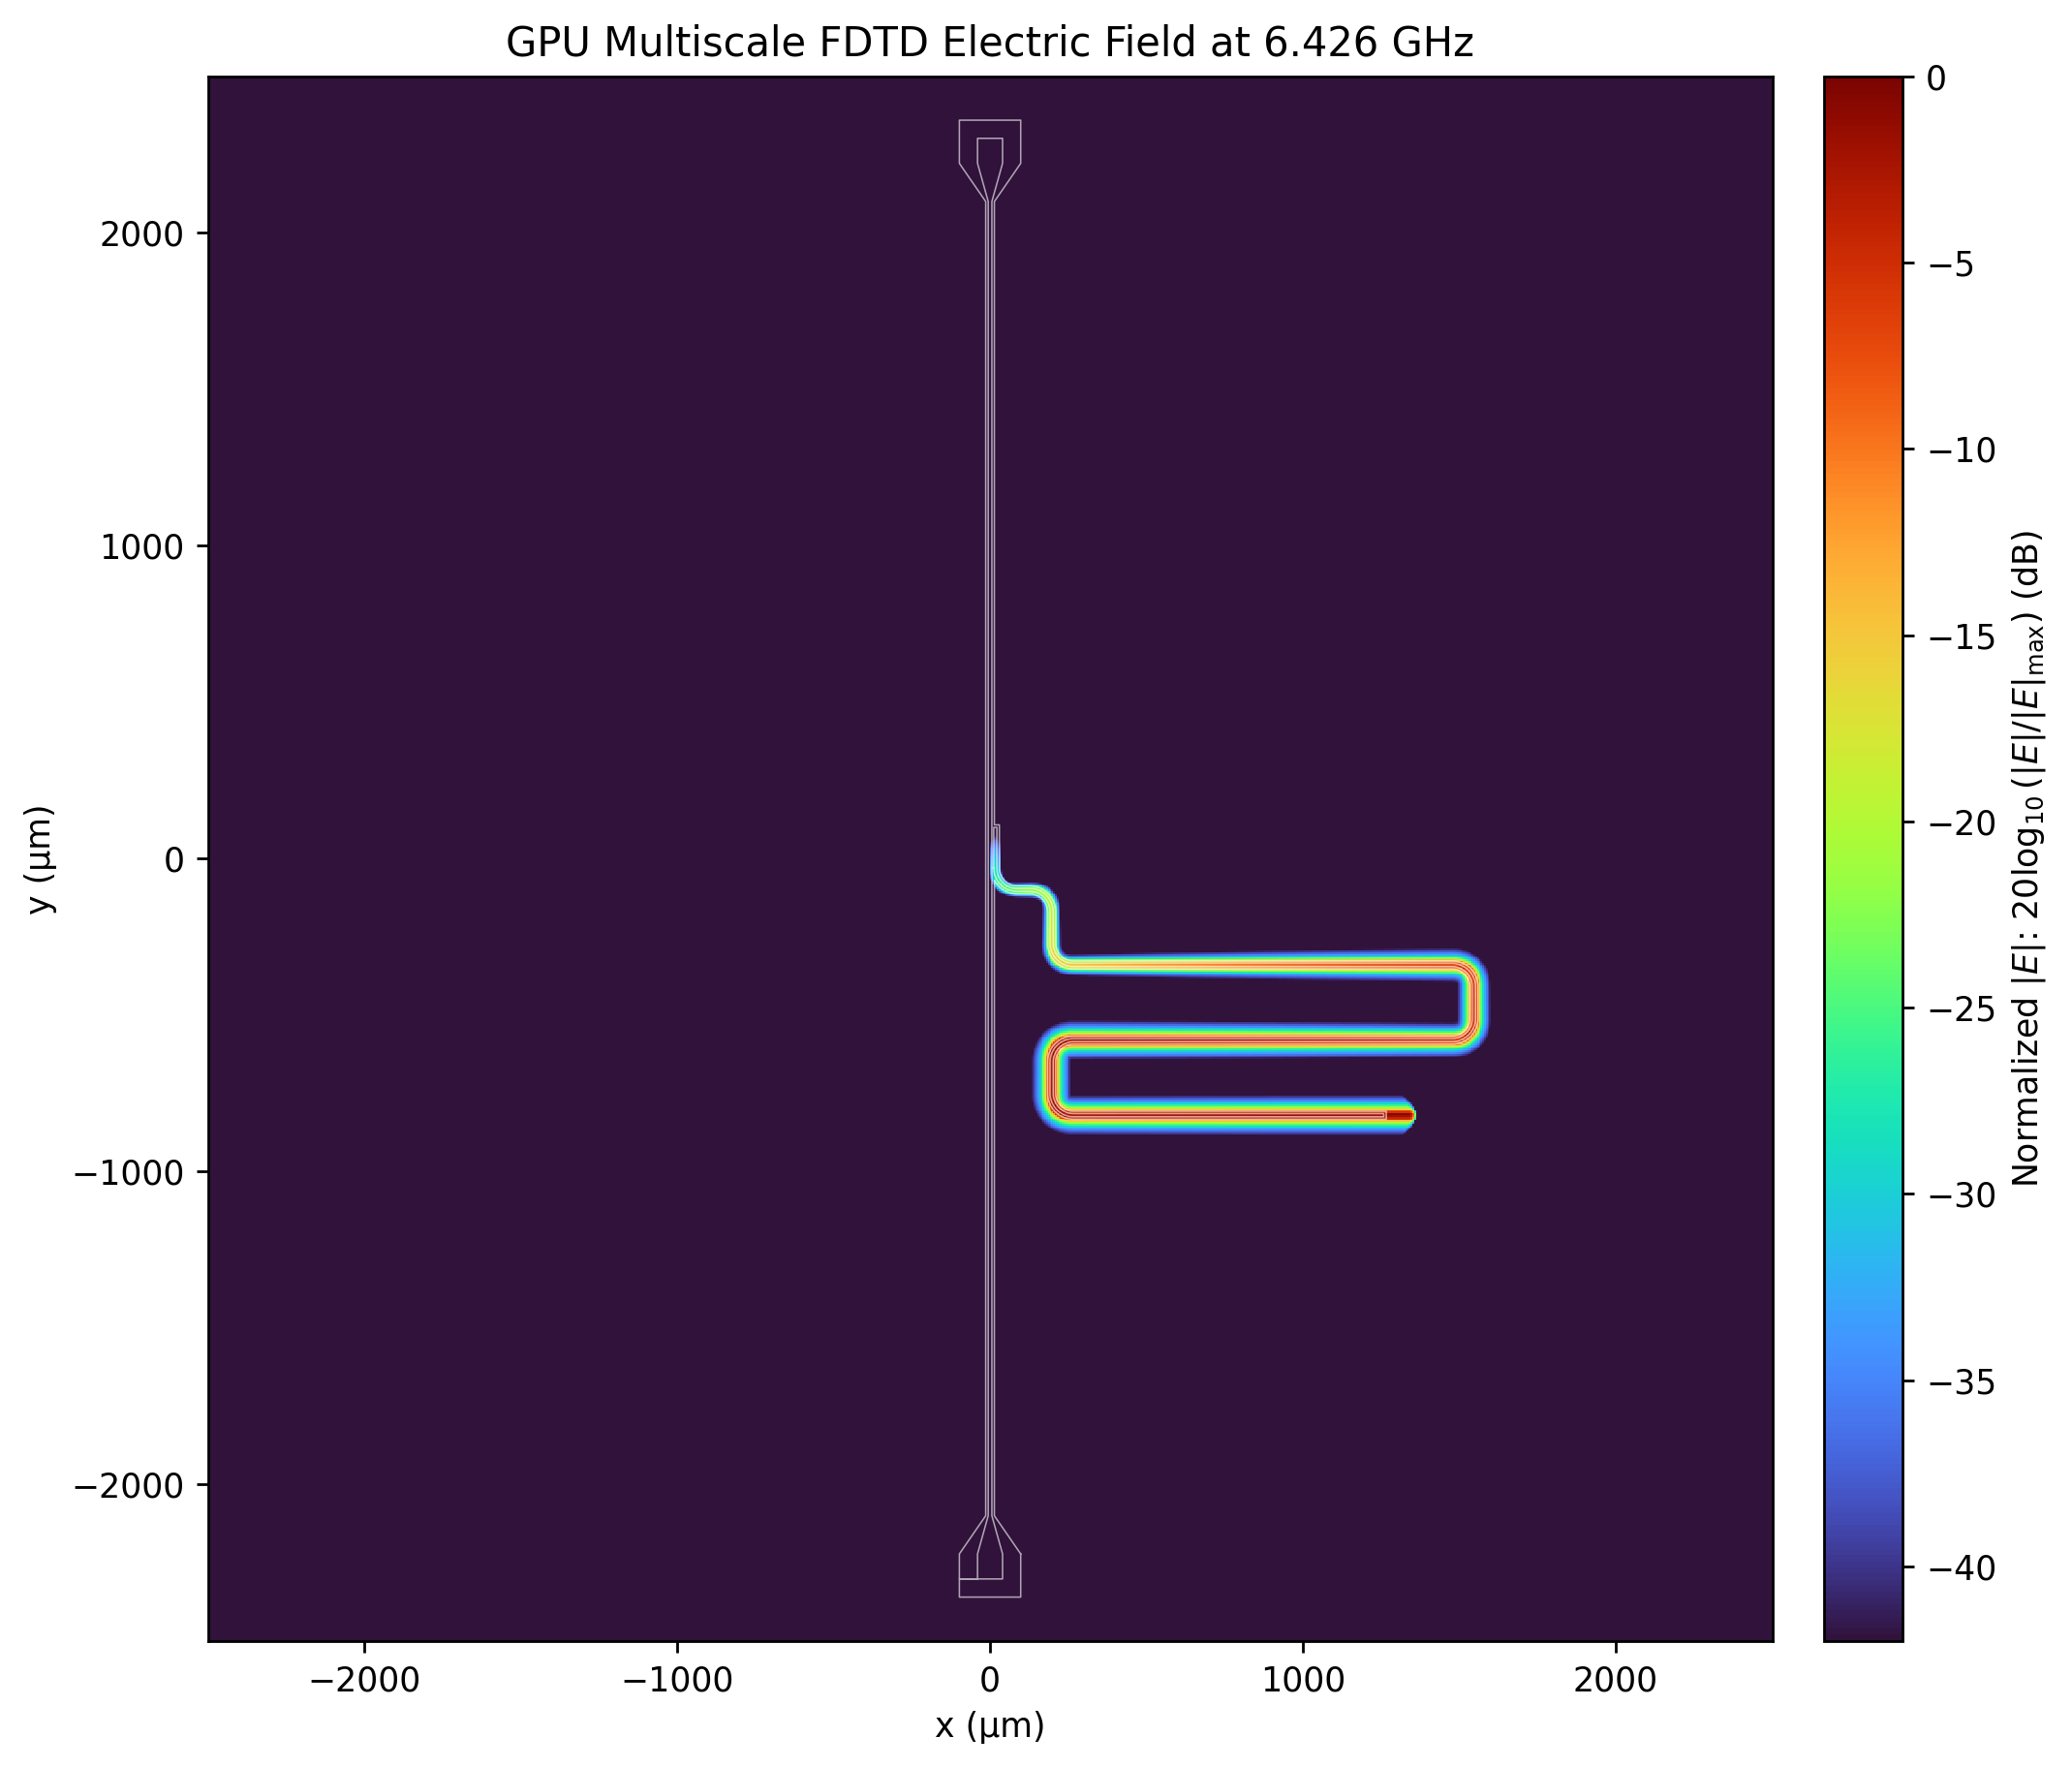


K3D electric-vector field
  glyph mode                  : closed_mesh
  arrows                      : 2,400
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 6.4, 14.0, 27.6)
  RF display phase            : 91.28 degrees



GPU multiscale adjacency-FDTD result
  Backend                     : graph_tem_gpu
  Selected frequency          : 6.426238 GHz
  FDTD spectral peak          : 6.426238 GHz
  Adjacency eigenfrequency    : 6.424665 GHz
  Quarter-wave estimate       : 6.450000 GHz
  Electrical path length      : 4651.16 µm
  Rendered centerline length  : 4676.63 µm
  Adjacency sparse backend    : False
  Cross-section linear solver : CSR + Jacobi-PCG
  Field domain                : chip
  Full field grid             : 894 × 895
  Field footprint             : 5000.0 × 5000.0 µm
  Metropolis-Hastings         : enabled
  MCMC observation source     : deterministic graph-FDTD consistency target
  MCMC posterior frequency    : 6.426059 ± 12.47 MHz
  MCMC acceptance rate        : 54.0%
  MCMC retained samples       : 7,168
  Heatmap PNG                 : /content/gpu_fdtd_cpw_fundamental_mode/electric_field_mode_gpu_fdtd.png
  K3D HTML                    : /content/gpu_fdtd_cpw_fundamental_mode/electric_fiel

In [5]:
"""Solve and visualize the CPW fundamental mode with a self-managed GPU solver.

The adaptive planner recognizes the micrometer-feature to microwave-wavelength
scale separation of this planar CPW and selects a multiscale CuPy backend:

1. A nearest-neighbor graph FDTD solve advances the longitudinal quasi-TEM
   voltage/current state inside a CUDA kernel.
2. A GPU transverse electrostatic solve computes the local CPW cross-section.
   The planner can use a matrix-free red-black SOR backend or a sparse
   conjugate-gradient backend assembled from the same five-point stencil.
3. A sparse or dense adjacency eigensolve independently estimates the
   short-open fundamental and cross-checks the FDTD spectral peak.
4. An optional batched Metropolis-Hastings layer runs on CuPy tensors to
   calibrate a reduced-order resonance surrogate and quantify uncertainty.
5. The coupled solution reconstructs the complex electric-field phasor over
   the complete chip footprint for Matplotlib and K3D.

Sparse linear algebra and stochastic calibration are self-managed in ``auto``
mode and can be overridden with the control knobs below. The deterministic
Maxwell solve always remains the primary field solution.
"""

import math
import socket
import threading
import time
from dataclasses import dataclass
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from typing import Final
from urllib.parse import quote

import cupy as cp
import cupyx.scipy.sparse as cpx_sparse
import cupyx.scipy.sparse.linalg as cpx_sparse_linalg
import gdstk
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import IFrame, display
from k3d.colormaps import matplotlib_color_maps
from k3d.helpers import map_colors


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

OUTPUT_DIRECTORY: Final[Path] = Path(
    "/content/gpu_fdtd_cpw_fundamental_mode"
)
HEATMAP_PATH: Final[Path] = (
    OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd.png"
)
K3D_HTML_PATH: Final[Path] = (
    OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd_k3d.html"
)

# Automatic planning is the default. The currently implemented backend is the
# multiscale quasi-TEM graph-FDTD solver selected for this CPW regime.
SOLVER_MODE: Final[str] = "auto"
VALID_SOLVER_MODES: Final[tuple[str, ...]] = (
    "auto",
    "graph_tem_gpu",
)

# Set any of these to a number to override the automatic planner.
FORCE_MODE_FREQUENCY_GHZ: Final[float | None] = None
FORCE_GRAPH_NODES: Final[int | None] = None
FORCE_LOADED_Q: Final[float | None] = None
FORCE_FIELD_GRID_NX: Final[int | None] = None
FORCE_FIELD_GRID_NY: Final[int | None] = None
FORCE_CROSS_SECTION_NU: Final[int | None] = None
FORCE_CROSS_SECTION_NZ: Final[int | None] = None

TARGET_FREQUENCY_GHZ: Final[float] = float(
    globals().get(
        "TARGET_RESONATOR_FREQUENCY_GHZ",
        6.45,
    )
)

SUBSTRATE_EPS_R: Final[float] = 11.45
USE_LAYOUT_PHASE_VELOCITY: Final[bool] = True
PHASE_VELOCITY_OVERRIDE_M_PER_S: Final[float | None] = None

# Graph-FDTD controls.
GRAPH_CFL: Final[float] = 0.92
GRAPH_MIN_NODES: Final[int] = 128
GRAPH_MAX_NODES: Final[int] = 768
GRAPH_TARGET_NODES_PER_GUIDED_WAVELENGTH: Final[int] = 140
GRAPH_MIN_NODES_PER_GEOMETRIC_SEGMENT: Final[int] = 12

DISCOVERY_CYCLES: Final[float] = 42.0
DISCOVERY_SEARCH_MIN_RATIO: Final[float] = 0.55
DISCOVERY_SEARCH_MAX_RATIO: Final[float] = 1.45
DISCOVERY_ZERO_PAD_FACTOR: Final[int] = 8
DISCOVERY_MIN_PEAK_TO_MEDIAN: Final[float] = 8.0

DRIVE_WARMUP_CYCLES: Final[float] = 22.0
DRIVE_ACCUMULATION_CYCLES: Final[float] = 8.0
DRIVE_SOURCE_AMPLITUDE: Final[float] = 0.05
DISCOVERY_SOURCE_AMPLITUDE: Final[float] = 0.10

# Cross-sectional finite-difference electrostatic solve.
CROSS_SECTION_CELLS_PER_GAP: Final[float] = 7.0
CROSS_SECTION_HALF_SPAN_FACTOR: Final[float] = 8.0
CROSS_SECTION_MIN_HALF_SPAN_UM: Final[float] = 90.0
CROSS_SECTION_AIR_HEIGHT_FACTOR: Final[float] = 8.0
CROSS_SECTION_SUBSTRATE_DEPTH_FACTOR: Final[float] = 8.0
CROSS_SECTION_MIN_VERTICAL_SPAN_UM: Final[float] = 90.0
CROSS_SECTION_MIN_NU: Final[int] = 129
CROSS_SECTION_MAX_NU: Final[int] = 321
CROSS_SECTION_MIN_NZ: Final[int] = 129
CROSS_SECTION_MAX_NZ: Final[int] = 321
CROSS_SECTION_SOR_OMEGA: Final[float] = 1.84
CROSS_SECTION_MIN_ITERATIONS: Final[int] = 900
CROSS_SECTION_MAX_ITERATIONS: Final[int] = 2600

# Sparse GPU linear-algebra controls.
#
# ``auto`` uses sparse matrices only after the problem is large enough for the
# lower asymptotic cost to outweigh CSR assembly overhead. ``on`` forces the
# sparse route whenever the requested operation supports it, and ``off`` keeps
# the dense adjacency plus red-black SOR paths.
SPARSE_MATRIX_MODE: Final[str] = "auto"
VALID_SPARSE_MATRIX_MODES: Final[tuple[str, ...]] = (
    "auto",
    "on",
    "off",
)
SPARSE_ADJACENCY_MIN_NODES: Final[int] = 320
SPARSE_CROSS_SECTION_MIN_UNKNOWNS: Final[int] = 18_000
SPARSE_MAX_GPU_MEMORY_FRACTION: Final[float] = 0.15
SPARSE_EIGSH_TOLERANCE: Final[float] = 1.0e-9
SPARSE_CG_RTOL: Final[float] = 2.0e-5
SPARSE_CG_ATOL: Final[float] = 0.0
SPARSE_CG_MAX_ITERATIONS: Final[int] = 1_800
SPARSE_CG_FALLBACK_TO_SOR: Final[bool] = True

# GPU Metropolis-Hastings calibration controls.
#
# The MCMC layer is a reduced-order calibration/uncertainty calculation. It
# does not replace FDTD or the transverse field solve. In ``auto`` mode it runs
# after the deterministic solution and uses the numerical resonance as an
# internal consistency observation unless a measured frequency is supplied.
MCMC_MODE: Final[str] = "auto"
VALID_MCMC_MODES: Final[tuple[str, ...]] = (
    "auto",
    "on",
    "off",
)
MCMC_OBSERVED_FREQUENCY_GHZ: Final[float | None] = None
MCMC_USE_NUMERICAL_FREQUENCY_AS_OBSERVATION: Final[bool] = True
MCMC_CHAINS: Final[int] = 64
MCMC_STEPS: Final[int] = 320
MCMC_BURN_IN: Final[int] = 96
MCMC_THIN: Final[int] = 2
MCMC_RANDOM_SEED: Final[int] = 20260824
MCMC_PHASE_VELOCITY_PRIOR_SIGMA: Final[float] = 0.020
MCMC_LENGTH_PRIOR_SIGMA: Final[float] = 0.0035
MCMC_PROPOSAL_SIGMA_PHASE_VELOCITY: Final[float] = 0.0030
MCMC_PROPOSAL_SIGMA_LENGTH: Final[float] = 0.0012
MCMC_MIN_OBSERVATION_SIGMA_MHZ: Final[float] = 8.0
MCMC_LINEWIDTH_SIGMA_FRACTION: Final[float] = 0.25

# Reconstructed field-grid controls.
#
# ``chip`` evaluates the reconstructed mode over the complete lithographic chip
# footprint supplied by the preceding PHIDL/GDSTK cell. ``active_region`` keeps
# the earlier resonator-local window for rapid diagnostic runs.
FIELD_DOMAIN_MODE: Final[str] = "chip"
VALID_FIELD_DOMAIN_MODES: Final[tuple[str, ...]] = (
    "chip",
    "active_region",
)
FIELD_CHIP_EDGE_PADDING_UM: Final[float] = 0.0
FIELD_ACTIVE_MARGIN_FACTOR: Final[float] = 5.0
FIELD_ACTIVE_MIN_MARGIN_UM: Final[float] = 90.0

# The full 5 mm × 5 mm chip needs more samples than the earlier local window.
# The planner keeps a finite pixel budget and preserves the square chip extent.
FIELD_TARGET_PIXEL_COUNT: Final[int] = 800_000
FIELD_MIN_AXIS_POINTS: Final[int] = 360
FIELD_MAX_AXIS_POINTS: Final[int] = 900
FIELD_HEIGHT_UM: Final[float] = 2.0
FIELD_DB_FLOOR: Final[float] = -42.0

# The transverse quasi-TEM solution is local to the CPW. A cosine taper based
# on the true Euclidean distance to the resonator path suppresses endpoint
# wedges and prevents clipped cross-section values from leaking across the chip.
FIELD_PATH_SUPPORT_RADIUS_FACTOR: Final[float] = 1.0
FIELD_PATH_TAPER_START_FRACTION: Final[float] = 0.78

# K3D controls.
K3D_BACKGROUND_COLOR: Final[int] = 0xFFFFFF
K3D_GRID_COLOR: Final[int] = 0xD5D5D5
K3D_LABEL_COLOR: Final[int] = 0x303030
K3D_SLOT_OUTLINE_COLOR: Final[int] = 0x404040
K3D_COMPRESSION_LEVEL: Final[int] = 6
K3D_ANTIALIAS_LEVEL: Final[int] = 3
K3D_SCREENSHOT_SCALE: Final[float] = 2.0
K3D_PLOT_HEIGHT: Final[int] = 720
K3D_SHOW_REFERENCE_GRID: Final[bool] = True
K3D_SHOW_AXIS_LABELS: Final[bool] = False
K3D_HEATMAP_OPACITY: Final[float] = 0.72
K3D_HEATMAP_Z_OFFSET_UM: Final[float] = 0.20
K3D_HEATMAP_MAX_AXIS_POINTS: Final[int] = 480
K3D_ARROW_THRESHOLD_DB: Final[float] = -32.0
K3D_MAX_ARROWS: Final[int] = 2_400
K3D_ARROW_MAX_LENGTH_UM: Final[float] = 38.0
K3D_ARROW_MAGNITUDE_EXPONENT: Final[float] = 0.42
K3D_RANDOM_SEED: Final[int] = 20260824
K3D_Z_LAYERS_UM: Final[tuple[float, ...] | None] = None

# Vector-glyph controls. ``closed_mesh`` reproduces the successful K3D style
# used in the earlier vector-field notebooks: a watertight cylindrical shaft
# plus an explicit cone with a capped base. ``builtin`` keeps k3d.vectors as a
# lighter browser fallback.
K3D_ARROW_GLYPH_MODE: Final[str] = "closed_mesh"
VALID_K3D_ARROW_GLYPH_MODES: Final[tuple[str, ...]] = (
    "closed_mesh",
    "builtin",
)
K3D_ARROW_LINE_WIDTH: Final[float] = 0.65
K3D_ARROW_HEAD_SIZE: Final[float] = 1.0
K3D_SHAFT_DIAMETER_UM: Final[float] = 1.20
K3D_SHAFT_RADIAL_SEGMENTS: Final[int] = 6
K3D_SHAFT_SHININESS: Final[float] = 28.0
K3D_CONE_LENGTH_MAX_UM: Final[float] = 7.5
K3D_CONE_LENGTH_FRACTION: Final[float] = 0.28
K3D_CONE_RADIUS_UM: Final[float] = 1.55
K3D_CONE_RADIAL_SEGMENTS: Final[int] = 8
K3D_CONE_SHININESS: Final[float] = 35.0
K3D_MIN_RENDER_VECTOR_LENGTH_UM: Final[float] = 0.35
K3D_KEEP_ARROWS_ABOVE_SURFACE: Final[bool] = True
K3D_ARROW_SURFACE_CLEARANCE_UM: Final[float] = 0.75

# Matplotlib controls.
FIGURE_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 7.4
SHOW_LAYOUT_OUTLINES_2D: Final[bool] = True

# Physical constant.
C_0_M_PER_S: Final[float] = 299_792_458.0


# ------------------------------------------------------------
# MATPLOTLIB CONFIGURATION
# ------------------------------------------------------------

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["savefig.dpi"] = FIGURE_DPI
mpl.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]
mpl.rcParams["font.weight"] = "normal"


# ------------------------------------------------------------
# DATA STRUCTURES
# ------------------------------------------------------------


@dataclass
class SolverPlan:
    """Store automatic regime classification and numerical discretization."""

    backend: str
    regime: str

    target_frequency_hz: float
    analytic_frequency_hz: float
    adjacency_frequency_hz: float

    phase_velocity_m_per_s: float
    wavelength_0_um: float
    wavelength_g_um: float
    resonator_length_um: float
    minimum_feature_um: float
    scale_separation: float

    explicit_3d_dx_estimate_um: float
    explicit_3d_cells_estimate: int
    explicit_3d_steps_per_cycle_estimate: float

    graph_nodes: int
    graph_ds_um: float
    graph_dt_s: float
    graph_steps_per_cycle: float
    discovery_steps: int
    drive_steps: int
    accumulation_start_step: int
    loaded_q: float

    field_domain_mode: str
    chip_size_x_um: float
    chip_size_y_um: float
    field_x_min_um: float
    field_x_max_um: float
    field_y_min_um: float
    field_y_max_um: float
    field_nx: int
    field_ny: int

    cross_u_min_um: float
    cross_u_max_um: float
    cross_z_min_um: float
    cross_z_max_um: float
    cross_nu: int
    cross_nz: int
    cross_iterations: int

    sparse_matrix_mode: str
    use_sparse_adjacency: bool
    use_sparse_cross_section: bool
    sparse_cross_unknown_estimate: int
    sparse_cross_memory_mib_estimate: float

    gpu_name: str
    gpu_free_gib: float
    gpu_total_gib: float


@dataclass
class GraphFDTDResult:
    """Store the longitudinal FDTD spectrum and complex voltage mode."""

    discovered_frequency_hz: float
    selected_frequency_hz: float
    peak_to_median_ratio: float
    monitor_time_s: np.ndarray
    monitor_voltage: np.ndarray
    spectrum_frequency_hz: np.ndarray
    spectrum_power: np.ndarray
    graph_s_um: np.ndarray
    voltage_phasor: np.ndarray


@dataclass
class CrossSectionField:
    """Store the normalized CPW transverse electrostatic field."""

    u_um: cp.ndarray
    z_um: cp.ndarray
    potential: cp.ndarray
    e_u_per_v: cp.ndarray
    e_z_per_v: cp.ndarray
    du_um: float
    dz_um: float
    linear_solver: str
    linear_solver_info: int


@dataclass
class MCMCResult:
    """Store GPU Metropolis-Hastings resonance calibration statistics."""

    enabled: bool
    observation_source: str
    observed_frequency_hz: float
    observation_sigma_hz: float
    posterior_frequency_mean_hz: float
    posterior_frequency_std_hz: float
    phase_velocity_scale_mean: float
    phase_velocity_scale_std: float
    length_scale_mean: float
    length_scale_std: float
    acceptance_rate: float
    retained_samples: int


@dataclass
class CenterlineGeometry:
    """Store a smoothed physical resonator centerline."""

    points_um: np.ndarray
    cumulative_s_um: np.ndarray
    total_length_um: float


@dataclass
class ReconstructedField:
    """Store one reconstructed complex electric-field plane."""

    x_um: np.ndarray
    y_um: np.ndarray
    e_complex_xyz: np.ndarray
    magnitude: np.ndarray
    magnitude_db: np.ndarray
    nearest_s_um: np.ndarray
    signed_u_um: np.ndarray
    normal_x: np.ndarray
    normal_y: np.ndarray


# ------------------------------------------------------------
# INPUT AND GPU DIAGNOSTICS
# ------------------------------------------------------------


def require_layout_result():
    """Return the PHIDL and GDSTK layout produced by the preceding cell."""
    result = globals().get("layout_result")

    if result is None:
        raise RuntimeError(
            "Run the PHIDL + GDSTK layout cell first so that "
            "`layout_result` exists."
        )

    return result


def get_gpu_information() -> tuple[str, float, float]:
    """Return CUDA device name and free/total VRAM in GiB."""
    device_count = cp.cuda.runtime.getDeviceCount()

    if device_count < 1:
        raise RuntimeError(
            "No CUDA GPU was detected. Select a GPU runtime in Google Colab."
        )

    properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name = properties["name"]

    if isinstance(device_name, bytes):
        device_name = device_name.decode("utf-8")

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()

    return (
        str(device_name),
        free_bytes / 2**30,
        total_bytes / 2**30,
    )


def synchronize_gpu() -> None:
    """Synchronize the active CUDA stream for reliable timing."""
    cp.cuda.Stream.null.synchronize()


# ------------------------------------------------------------
# AUTOMATIC REGIME AND COST PLANNER
# ------------------------------------------------------------


def odd_clamped(value: int, lower: int, upper: int) -> int:
    """Clamp an integer to an odd value inside the requested interval."""
    result = max(lower, min(upper, int(value)))

    if result % 2 == 0:
        result += 1

    if result > upper:
        result -= 2

    return result


def choose_field_grid(
    x_span_um: float,
    y_span_um: float,
) -> tuple[int, int]:
    """Choose a field-grid shape near the target pixel count."""
    if FORCE_FIELD_GRID_NX is not None and FORCE_FIELD_GRID_NY is not None:
        return (
            int(FORCE_FIELD_GRID_NX),
            int(FORCE_FIELD_GRID_NY),
        )

    aspect = max(x_span_um / max(y_span_um, 1.0e-12), 1.0e-12)
    nx = int(round(math.sqrt(FIELD_TARGET_PIXEL_COUNT * aspect)))
    ny = int(round(FIELD_TARGET_PIXEL_COUNT / max(nx, 1)))

    nx = max(FIELD_MIN_AXIS_POINTS, min(FIELD_MAX_AXIS_POINTS, nx))
    ny = max(FIELD_MIN_AXIS_POINTS, min(FIELD_MAX_AXIS_POINTS, ny))

    if FORCE_FIELD_GRID_NX is not None:
        nx = int(FORCE_FIELD_GRID_NX)

    if FORCE_FIELD_GRID_NY is not None:
        ny = int(FORCE_FIELD_GRID_NY)

    return nx, ny


def build_adjacency_fundamental_frequency(
    graph_nodes: int,
    graph_ds_um: float,
    phase_velocity_m_per_s: float,
    use_sparse: bool,
) -> float:
    """Calculate the short-open path-graph fundamental on the GPU."""
    unknown_nodes = graph_nodes - 1

    diagonal = cp.full(
        unknown_nodes,
        2.0,
        dtype=cp.float64,
    )
    diagonal[-1] = 1.0

    off_diagonal = cp.full(
        max(unknown_nodes - 1, 0),
        -1.0,
        dtype=cp.float64,
    )

    lambda_0 = None

    if use_sparse and unknown_nodes >= 4:
        try:
            stiffness = cpx_sparse.diags(
                diagonals=(
                    off_diagonal,
                    diagonal,
                    off_diagonal,
                ),
                offsets=(-1, 0, 1),
                shape=(unknown_nodes, unknown_nodes),
                format="csr",
                dtype=cp.float64,
            )

            eigenvalues = cpx_sparse_linalg.eigsh(
                stiffness,
                k=1,
                which="SA",
                tol=SPARSE_EIGSH_TOLERANCE,
                return_eigenvectors=False,
            )
            lambda_0 = float(cp.real(eigenvalues[0]).get())
        except Exception as error:
            print(
                "Sparse adjacency eigensolve fell back to the dense route: "
                f"{type(error).__name__}: {error}"
            )

    if lambda_0 is None:
        stiffness = cp.diag(diagonal)

        if unknown_nodes > 1:
            stiffness += cp.diag(off_diagonal, k=1)
            stiffness += cp.diag(off_diagonal, k=-1)

        eigenvalues = cp.linalg.eigvalsh(stiffness)
        lambda_0 = float(eigenvalues[0].get())

    ds_m = graph_ds_um * 1.0e-6
    angular_frequency = (
        phase_velocity_m_per_s
        * math.sqrt(max(lambda_0, 0.0))
        / ds_m
    )

    return angular_frequency / (2.0 * math.pi)


def build_solver_plan(layout) -> SolverPlan:
    """Classify the electromagnetic regime and choose numerical controls."""
    if SOLVER_MODE not in VALID_SOLVER_MODES:
        raise ValueError(
            f"SOLVER_MODE must be one of {VALID_SOLVER_MODES}; "
            f"received {SOLVER_MODE!r}."
        )

    if SPARSE_MATRIX_MODE not in VALID_SPARSE_MATRIX_MODES:
        raise ValueError(
            "SPARSE_MATRIX_MODE must be one of "
            f"{VALID_SPARSE_MATRIX_MODES}; received {SPARSE_MATRIX_MODE!r}."
        )

    if MCMC_MODE not in VALID_MCMC_MODES:
        raise ValueError(
            f"MCMC_MODE must be one of {VALID_MCMC_MODES}; "
            f"received {MCMC_MODE!r}."
        )

    if FIELD_DOMAIN_MODE not in VALID_FIELD_DOMAIN_MODES:
        raise ValueError(
            "FIELD_DOMAIN_MODE must be one of "
            f"{VALID_FIELD_DOMAIN_MODES}; received {FIELD_DOMAIN_MODE!r}."
        )

    if K3D_ARROW_GLYPH_MODE not in VALID_K3D_ARROW_GLYPH_MODES:
        raise ValueError(
            "K3D_ARROW_GLYPH_MODE must be one of "
            f"{VALID_K3D_ARROW_GLYPH_MODES}; "
            f"received {K3D_ARROW_GLYPH_MODE!r}."
        )

    gpu_name, gpu_free_gib, gpu_total_gib = get_gpu_information()

    resonator_points = np.asarray(
        layout.resonator_points,
        dtype=np.float64,
    )

    resonator_length_um = float(
        getattr(
            layout,
            "resonator_rounded_length_um",
            0.0,
        )
    )

    if resonator_length_um <= 0.0:
        resonator_length_um = float(
            np.sum(
                np.linalg.norm(
                    np.diff(resonator_points, axis=0),
                    axis=1,
                )
            )
        )

    feedline_width_um = float(
        globals().get("FEEDLINE_TRACE_WIDTH_UM", 11.7)
    )
    feedline_gap_um = float(
        globals().get("FEEDLINE_TRACE_GAP_UM", 8.0)
    )
    resonator_width_um = float(
        globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)
    )
    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 8.0)
    )
    coupling_space_um = float(
        globals().get("RESONATOR_COUPLING_SPACE_UM", 6.0)
    )

    minimum_feature_um = min(
        feedline_width_um,
        feedline_gap_um,
        resonator_width_um,
        resonator_gap_um,
        coupling_space_um,
    )

    if PHASE_VELOCITY_OVERRIDE_M_PER_S is not None:
        phase_velocity = float(PHASE_VELOCITY_OVERRIDE_M_PER_S)
    elif USE_LAYOUT_PHASE_VELOCITY and "CPW_PHASE_VELOCITY_M_PER_S" in globals():
        phase_velocity = float(globals()["CPW_PHASE_VELOCITY_M_PER_S"])
    else:
        epsilon_eff = 0.5 * (1.0 + SUBSTRATE_EPS_R)
        phase_velocity = C_0_M_PER_S / math.sqrt(epsilon_eff)

    target_frequency_hz = (
        float(FORCE_MODE_FREQUENCY_GHZ) * 1.0e9
        if FORCE_MODE_FREQUENCY_GHZ is not None
        else TARGET_FREQUENCY_GHZ * 1.0e9
    )

    analytic_frequency_hz = (
        phase_velocity
        / (4.0 * resonator_length_um * 1.0e-6)
    )

    wavelength_0_um = C_0_M_PER_S / target_frequency_hz * 1.0e6
    wavelength_g_um = phase_velocity / target_frequency_hz * 1.0e6
    scale_separation = wavelength_g_um / minimum_feature_um

    geometric_segment_count = max(resonator_points.shape[0] - 1, 1)

    auto_graph_nodes = max(
        GRAPH_MIN_NODES,
        int(
            math.ceil(
                resonator_length_um
                / (wavelength_g_um / GRAPH_TARGET_NODES_PER_GUIDED_WAVELENGTH)
            )
        )
        + 1,
        geometric_segment_count * GRAPH_MIN_NODES_PER_GEOMETRIC_SEGMENT + 1,
    )

    graph_nodes = (
        int(FORCE_GRAPH_NODES)
        if FORCE_GRAPH_NODES is not None
        else auto_graph_nodes
    )
    graph_nodes = max(GRAPH_MIN_NODES, min(GRAPH_MAX_NODES, graph_nodes))

    graph_ds_um = resonator_length_um / (graph_nodes - 1)
    graph_dt_s = (
        GRAPH_CFL
        * graph_ds_um
        * 1.0e-6
        / phase_velocity
    )
    graph_steps_per_cycle = 1.0 / (target_frequency_hz * graph_dt_s)

    use_sparse_adjacency = (
        SPARSE_MATRIX_MODE == "on"
        or (
            SPARSE_MATRIX_MODE == "auto"
            and graph_nodes >= SPARSE_ADJACENCY_MIN_NODES
        )
    )

    adjacency_frequency_hz = build_adjacency_fundamental_frequency(
        graph_nodes=graph_nodes,
        graph_ds_um=graph_ds_um,
        phase_velocity_m_per_s=phase_velocity,
        use_sparse=use_sparse_adjacency,
    )

    loaded_q = (
        float(FORCE_LOADED_Q)
        if FORCE_LOADED_Q is not None
        else float(np.clip(70.0 + 0.018 * scale_separation, 90.0, 170.0))
    )

    discovery_steps = int(
        math.ceil(DISCOVERY_CYCLES * graph_steps_per_cycle)
    )
    drive_steps = int(
        math.ceil(
            (DRIVE_WARMUP_CYCLES + DRIVE_ACCUMULATION_CYCLES)
            * graph_steps_per_cycle
        )
    )
    accumulation_start_step = int(
        math.ceil(DRIVE_WARMUP_CYCLES * graph_steps_per_cycle)
    )

    trace_outer_half_um = 0.5 * resonator_width_um + resonator_gap_um

    chip_size_x_um = float(
        globals().get("CHIP_SIZE_X_UM", 5000.0)
    )
    chip_size_y_um = float(
        globals().get("CHIP_SIZE_Y_UM", 5000.0)
    )

    if chip_size_x_um <= 0.0 or chip_size_y_um <= 0.0:
        raise ValueError(
            "CHIP_SIZE_X_UM and CHIP_SIZE_Y_UM must both be positive."
        )

    if FIELD_DOMAIN_MODE == "chip":
        chip_padding_um = max(float(FIELD_CHIP_EDGE_PADDING_UM), 0.0)
        x_min = -0.5 * chip_size_x_um - chip_padding_um
        x_max = 0.5 * chip_size_x_um + chip_padding_um
        y_min = -0.5 * chip_size_y_um - chip_padding_um
        y_max = 0.5 * chip_size_y_um + chip_padding_um
    else:
        field_margin_um = max(
            FIELD_ACTIVE_MIN_MARGIN_UM,
            FIELD_ACTIVE_MARGIN_FACTOR * trace_outer_half_um,
        )
        x_min = float(np.min(resonator_points[:, 0]) - field_margin_um)
        x_max = float(np.max(resonator_points[:, 0]) + field_margin_um)
        y_min = float(np.min(resonator_points[:, 1]) - field_margin_um)
        y_max = float(np.max(resonator_points[:, 1]) + field_margin_um)

    field_nx, field_ny = choose_field_grid(
        x_span_um=x_max - x_min,
        y_span_um=y_max - y_min,
    )

    half_span_u = max(
        CROSS_SECTION_MIN_HALF_SPAN_UM,
        CROSS_SECTION_HALF_SPAN_FACTOR * trace_outer_half_um,
    )
    air_height = max(
        CROSS_SECTION_MIN_VERTICAL_SPAN_UM,
        CROSS_SECTION_AIR_HEIGHT_FACTOR * resonator_gap_um,
    )
    substrate_depth = max(
        CROSS_SECTION_MIN_VERTICAL_SPAN_UM,
        CROSS_SECTION_SUBSTRATE_DEPTH_FACTOR * resonator_gap_um,
    )

    target_cross_step_um = resonator_gap_um / CROSS_SECTION_CELLS_PER_GAP

    auto_nu = int(math.ceil(2.0 * half_span_u / target_cross_step_um)) + 1
    auto_nz = int(math.ceil((air_height + substrate_depth) / target_cross_step_um)) + 1

    cross_nu = (
        int(FORCE_CROSS_SECTION_NU)
        if FORCE_CROSS_SECTION_NU is not None
        else odd_clamped(auto_nu, CROSS_SECTION_MIN_NU, CROSS_SECTION_MAX_NU)
    )
    cross_nz = (
        int(FORCE_CROSS_SECTION_NZ)
        if FORCE_CROSS_SECTION_NZ is not None
        else odd_clamped(auto_nz, CROSS_SECTION_MIN_NZ, CROSS_SECTION_MAX_NZ)
    )

    cross_iterations = int(
        np.clip(
            5 * max(cross_nu, cross_nz),
            CROSS_SECTION_MIN_ITERATIONS,
            CROSS_SECTION_MAX_ITERATIONS,
        )
    )

    sparse_cross_unknown_estimate = max(
        (cross_nu - 2) * (cross_nz - 2),
        1,
    )
    sparse_cross_nnz_estimate = 5 * sparse_cross_unknown_estimate
    sparse_cross_memory_bytes = (
        sparse_cross_nnz_estimate * (4 + 4)
        + (sparse_cross_unknown_estimate + 1) * 4
        + sparse_cross_unknown_estimate * 6 * 4
    )
    sparse_cross_memory_mib_estimate = sparse_cross_memory_bytes / 2**20
    sparse_memory_allowed = (
        sparse_cross_memory_bytes
        <= SPARSE_MAX_GPU_MEMORY_FRACTION * gpu_free_gib * 2**30
    )

    use_sparse_cross_section = (
        SPARSE_MATRIX_MODE == "on"
        or (
            SPARSE_MATRIX_MODE == "auto"
            and sparse_cross_unknown_estimate
            >= SPARSE_CROSS_SECTION_MIN_UNKNOWNS
            and sparse_memory_allowed
        )
    )

    # Estimate why a direct explicit 3D Yee solve is unsuitable here.
    explicit_dx_um = minimum_feature_um / 3.0
    explicit_z_span_um = air_height + substrate_depth
    explicit_nx = max(2, int(math.ceil((x_max - x_min) / explicit_dx_um)))
    explicit_ny = max(2, int(math.ceil((y_max - y_min) / explicit_dx_um)))
    explicit_nz = max(2, int(math.ceil(explicit_z_span_um / explicit_dx_um)))
    explicit_cells = explicit_nx * explicit_ny * explicit_nz

    explicit_dt_s = (
        0.95
        / (
            C_0_M_PER_S
            * math.sqrt(3.0)
            / (explicit_dx_um * 1.0e-6)
        )
    )
    explicit_steps_per_cycle = 1.0 / (target_frequency_hz * explicit_dt_s)

    regime = "planar quasi-TEM, severe multiscale separation"
    backend = "graph_tem_gpu"

    return SolverPlan(
        backend=backend,
        regime=regime,
        target_frequency_hz=target_frequency_hz,
        analytic_frequency_hz=analytic_frequency_hz,
        adjacency_frequency_hz=adjacency_frequency_hz,
        phase_velocity_m_per_s=phase_velocity,
        wavelength_0_um=wavelength_0_um,
        wavelength_g_um=wavelength_g_um,
        resonator_length_um=resonator_length_um,
        minimum_feature_um=minimum_feature_um,
        scale_separation=scale_separation,
        explicit_3d_dx_estimate_um=explicit_dx_um,
        explicit_3d_cells_estimate=explicit_cells,
        explicit_3d_steps_per_cycle_estimate=explicit_steps_per_cycle,
        graph_nodes=graph_nodes,
        graph_ds_um=graph_ds_um,
        graph_dt_s=graph_dt_s,
        graph_steps_per_cycle=graph_steps_per_cycle,
        discovery_steps=discovery_steps,
        drive_steps=drive_steps,
        accumulation_start_step=accumulation_start_step,
        loaded_q=loaded_q,
        field_domain_mode=FIELD_DOMAIN_MODE,
        chip_size_x_um=chip_size_x_um,
        chip_size_y_um=chip_size_y_um,
        field_x_min_um=x_min,
        field_x_max_um=x_max,
        field_y_min_um=y_min,
        field_y_max_um=y_max,
        field_nx=field_nx,
        field_ny=field_ny,
        cross_u_min_um=-half_span_u,
        cross_u_max_um=half_span_u,
        cross_z_min_um=-substrate_depth,
        cross_z_max_um=air_height,
        cross_nu=cross_nu,
        cross_nz=cross_nz,
        cross_iterations=cross_iterations,
        sparse_matrix_mode=SPARSE_MATRIX_MODE,
        use_sparse_adjacency=use_sparse_adjacency,
        use_sparse_cross_section=use_sparse_cross_section,
        sparse_cross_unknown_estimate=sparse_cross_unknown_estimate,
        sparse_cross_memory_mib_estimate=sparse_cross_memory_mib_estimate,
        gpu_name=gpu_name,
        gpu_free_gib=gpu_free_gib,
        gpu_total_gib=gpu_total_gib,
    )


def print_solver_plan(plan: SolverPlan) -> None:
    """Print the automatic solver decision and cost estimates."""
    print("Adaptive GPU electromagnetic solver")
    print(f"  GPU                         : {plan.gpu_name}")
    print(f"  Free / total VRAM           : {plan.gpu_free_gib:.2f} / {plan.gpu_total_gib:.2f} GiB")
    print(f"  Detected regime             : {plan.regime}")
    print(f"  Selected backend            : {plan.backend}")
    print(f"  Target frequency            : {plan.target_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Quarter-wave estimate       : {plan.analytic_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Adjacency eigenfrequency    : {plan.adjacency_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Guided wavelength           : {plan.wavelength_g_um / 1000.0:.3f} mm")
    print(f"  Minimum layout feature      : {plan.minimum_feature_um:.3f} µm")
    print(f"  Scale-separation ratio      : {plan.scale_separation:,.0f} : 1")
    print()
    print("Explicit full-volume Yee estimate")
    print(f"  Nominal cell size           : {plan.explicit_3d_dx_estimate_um:.3f} µm")
    print(f"  Approximate cell count      : {plan.explicit_3d_cells_estimate:,}")
    print(f"  Timesteps per RF cycle      : {plan.explicit_3d_steps_per_cycle_estimate:,.0f}")
    print()
    print("Selected graph-FDTD discretization")
    print(f"  Graph nodes                 : {plan.graph_nodes:,}")
    print(f"  Longitudinal spacing        : {plan.graph_ds_um:.3f} µm")
    print(f"  Timesteps per RF cycle      : {plan.graph_steps_per_cycle:.1f}")
    print(f"  Discovery timesteps         : {plan.discovery_steps:,}")
    print(f"  Driven-mode timesteps       : {plan.drive_steps:,}")
    print(f"  Loaded-Q model              : {plan.loaded_q:.1f}")
    print()
    print("GPU sparse / transverse solve")
    print(f"  Sparse matrix mode          : {plan.sparse_matrix_mode}")
    print(f"  Sparse adjacency eigensolve : {plan.use_sparse_adjacency}")
    print(f"  Cross-section grid          : {plan.cross_nu} × {plan.cross_nz}")
    print(f"  Approx. free unknowns       : {plan.sparse_cross_unknown_estimate:,}")
    print(f"  Sparse CSR memory estimate  : {plan.sparse_cross_memory_mib_estimate:.2f} MiB")
    print(f"  Sparse cross-section solve  : {plan.use_sparse_cross_section}")
    print(f"  SOR fallback iterations     : {plan.cross_iterations:,}")
    print()
    print("Full-chip field reconstruction")
    print(f"  Field domain mode           : {plan.field_domain_mode}")
    print(
        f"  Chip footprint              : "
        f"{plan.chip_size_x_um:.1f} × {plan.chip_size_y_um:.1f} µm"
    )
    print(
        f"  Solved x range              : "
        f"{plan.field_x_min_um:.1f} to {plan.field_x_max_um:.1f} µm"
    )
    print(
        f"  Solved y range              : "
        f"{plan.field_y_min_um:.1f} to {plan.field_y_max_um:.1f} µm"
    )
    print(f"  Reconstructed field grid    : {plan.field_nx} × {plan.field_ny}")


# ------------------------------------------------------------
# GPU GRAPH-FDTD KERNELS
# ------------------------------------------------------------

GRAPH_DISCOVERY_KERNEL = cp.RawKernel(
    r'''
    extern "C" __global__
    void graph_discovery(
        float* monitor,
        const int n_nodes,
        const int n_steps,
        const float courant,
        const float loss,
        const float source_amplitude,
        const int source_index,
        const float dt,
        const float source_frequency,
        const float pulse_center,
        const float pulse_sigma
    ) {
        extern __shared__ float shared[];
        float* voltage = shared;
        float* current_z = shared + n_nodes;

        const int tid = threadIdx.x;
        const float two_pi = 6.2831853071795864769f;

        if (tid < n_nodes) {
            voltage[tid] = 0.0f;
        }
        if (tid < n_nodes - 1) {
            current_z[tid] = 0.0f;
        }
        __syncthreads();

        for (int step = 0; step < n_steps; ++step) {
            if (tid < n_nodes - 1) {
                const float gradient_v = voltage[tid + 1] - voltage[tid];
                current_z[tid] = loss * (
                    current_z[tid] - courant * gradient_v
                );
            }
            __syncthreads();

            if (tid == 0) {
                voltage[0] = 0.0f;
            }
            else if (tid < n_nodes - 1) {
                const float divergence_i = current_z[tid] - current_z[tid - 1];
                voltage[tid] = loss * (
                    voltage[tid] - courant * divergence_i
                );
            }
            else if (tid == n_nodes - 1) {
                voltage[tid] = loss * (
                    voltage[tid] + courant * current_z[n_nodes - 2]
                );
            }
            __syncthreads();

            if (tid == source_index) {
                const float t = (step + 1) * dt;
                const float normalized = (t - pulse_center) / pulse_sigma;
                const float envelope = expf(-0.5f * normalized * normalized);
                const float carrier = sinf(
                    two_pi * source_frequency * (t - pulse_center)
                );
                voltage[tid] += source_amplitude * envelope * carrier;
            }
            __syncthreads();

            if (tid == n_nodes - 1) {
                monitor[step] = voltage[tid];
            }
            __syncthreads();
        }
    }
    ''',
    "graph_discovery",
)


GRAPH_PHASOR_KERNEL = cp.RawKernel(
    r'''
    extern "C" __global__
    void graph_phasor(
        float* phasor_real,
        float* phasor_imag,
        const int n_nodes,
        const int n_steps,
        const int accumulation_start,
        const float courant,
        const float loss,
        const float source_amplitude,
        const int source_index,
        const float dt,
        const float frequency,
        const float ramp_time
    ) {
        extern __shared__ float shared[];
        float* voltage = shared;
        float* current_z = shared + n_nodes;

        const int tid = threadIdx.x;
        const float two_pi = 6.2831853071795864769f;

        float accumulator_real = 0.0f;
        float accumulator_imag = 0.0f;
        int accumulator_count = 0;

        if (tid < n_nodes) {
            voltage[tid] = 0.0f;
        }
        if (tid < n_nodes - 1) {
            current_z[tid] = 0.0f;
        }
        __syncthreads();

        for (int step = 0; step < n_steps; ++step) {
            if (tid < n_nodes - 1) {
                const float gradient_v = voltage[tid + 1] - voltage[tid];
                current_z[tid] = loss * (
                    current_z[tid] - courant * gradient_v
                );
            }
            __syncthreads();

            if (tid == 0) {
                voltage[0] = 0.0f;
            }
            else if (tid < n_nodes - 1) {
                const float divergence_i = current_z[tid] - current_z[tid - 1];
                voltage[tid] = loss * (
                    voltage[tid] - courant * divergence_i
                );
            }
            else if (tid == n_nodes - 1) {
                voltage[tid] = loss * (
                    voltage[tid] + courant * current_z[n_nodes - 2]
                );
            }
            __syncthreads();

            const float t = (step + 1) * dt;

            if (tid == source_index) {
                const float ramp = 1.0f - expf(-t / fmaxf(ramp_time, 1.0e-20f));
                voltage[tid] += (
                    source_amplitude
                    * ramp
                    * sinf(two_pi * frequency * t)
                );
            }
            __syncthreads();

            if (step >= accumulation_start && tid < n_nodes) {
                const float phase = two_pi * frequency * t;
                accumulator_real += voltage[tid] * cosf(phase);
                accumulator_imag -= voltage[tid] * sinf(phase);
                accumulator_count += 1;
            }
            __syncthreads();
        }

        if (tid < n_nodes) {
            const float normalization = (
                accumulator_count > 0
                ? 2.0f / (float) accumulator_count
                : 0.0f
            );
            phasor_real[tid] = accumulator_real * normalization;
            phasor_imag[tid] = accumulator_imag * normalization;
        }
    }
    ''',
    "graph_phasor",
)


def next_power_of_two(value: int) -> int:
    """Return the next power of two greater than or equal to value."""
    return 1 << (int(value) - 1).bit_length()


def graph_kernel_launch_configuration(plan: SolverPlan) -> tuple[int, int]:
    """Return CUDA block size and shared-memory bytes for the graph kernel."""
    block_size = next_power_of_two(plan.graph_nodes)

    if block_size > 1024:
        raise RuntimeError(
            "The graph-FDTD planner exceeded the CUDA block-size limit. "
            "Lower FORCE_GRAPH_NODES or GRAPH_MAX_NODES."
        )

    shared_float_count = plan.graph_nodes + plan.graph_nodes - 1
    shared_bytes = shared_float_count * np.dtype(np.float32).itemsize

    return block_size, shared_bytes


def run_graph_discovery(plan: SolverPlan) -> tuple[np.ndarray, np.ndarray]:
    """Run the broadband short-open graph FDTD entirely on the GPU."""
    monitor_gpu = cp.zeros(plan.discovery_steps, dtype=cp.float32)
    block_size, shared_bytes = graph_kernel_launch_configuration(plan)

    source_index = min(3, plan.graph_nodes - 2)
    source_frequency = plan.target_frequency_hz

    spectral_sigma_hz = 0.36 * source_frequency
    pulse_sigma_s = 1.0 / (2.0 * math.pi * spectral_sigma_hz)
    pulse_center_s = 5.0 * pulse_sigma_s

    angular_reference = 2.0 * math.pi * plan.target_frequency_hz
    loss = math.exp(
        -angular_reference * plan.graph_dt_s / (2.0 * plan.loaded_q)
    )

    synchronize_gpu()
    start_time = time.perf_counter()

    GRAPH_DISCOVERY_KERNEL(
        (1,),
        (block_size,),
        (
            monitor_gpu,
            np.int32(plan.graph_nodes),
            np.int32(plan.discovery_steps),
            np.float32(GRAPH_CFL),
            np.float32(loss),
            np.float32(DISCOVERY_SOURCE_AMPLITUDE),
            np.int32(source_index),
            np.float32(plan.graph_dt_s),
            np.float32(source_frequency),
            np.float32(pulse_center_s),
            np.float32(pulse_sigma_s),
        ),
        shared_mem=shared_bytes,
    )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    monitor = cp.asnumpy(monitor_gpu)
    time_axis = (
        np.arange(plan.discovery_steps, dtype=np.float64)
        * plan.graph_dt_s
    )

    print(f"Graph-FDTD broadband discovery: {elapsed:.3f} s on {plan.gpu_name}")

    return time_axis, monitor


def analyze_discovery_spectrum(
    plan: SolverPlan,
    monitor_time_s: np.ndarray,
    monitor_voltage: np.ndarray,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    """Locate the fundamental resonance from the GPU FDTD ringdown spectrum."""
    source_frequency = plan.target_frequency_hz
    spectral_sigma_hz = 0.36 * source_frequency
    pulse_sigma_s = 1.0 / (2.0 * math.pi * spectral_sigma_hz)
    pulse_center_s = 5.0 * pulse_sigma_s
    tail_start_s = pulse_center_s + 4.0 * pulse_sigma_s

    tail_mask = monitor_time_s >= tail_start_s
    tail = monitor_voltage[tail_mask]

    if tail.size < 64:
        tail = monitor_voltage.copy()

    tail_gpu = cp.asarray(tail, dtype=cp.float32)
    tail_gpu = tail_gpu - cp.mean(tail_gpu)
    window = cp.hanning(tail_gpu.size).astype(cp.float32)
    signal = tail_gpu * window

    n_fft = next_power_of_two(max(signal.size, 64)) * DISCOVERY_ZERO_PAD_FACTOR
    spectrum_gpu = cp.fft.rfft(signal, n=n_fft)
    power_gpu = cp.abs(spectrum_gpu) ** 2
    frequency_gpu = cp.fft.rfftfreq(n_fft, d=plan.graph_dt_s)

    search_min = DISCOVERY_SEARCH_MIN_RATIO * plan.adjacency_frequency_hz
    search_max = DISCOVERY_SEARCH_MAX_RATIO * plan.adjacency_frequency_hz

    search_mask = (
        (frequency_gpu >= search_min)
        & (frequency_gpu <= search_max)
    )

    search_indices = cp.flatnonzero(search_mask)

    if int(search_indices.size) == 0:
        raise RuntimeError("The FDTD frequency-search window contains no FFT bins.")

    local_power = power_gpu[search_indices]
    peak_local_index = int(cp.argmax(local_power).get())
    peak_index = int(search_indices[peak_local_index].get())

    discovered_frequency = float(frequency_gpu[peak_index].get())
    peak_power = float(power_gpu[peak_index].get())
    median_power = float(cp.median(local_power).get())
    peak_to_median = peak_power / max(median_power, 1.0e-30)

    frequency = cp.asnumpy(frequency_gpu)
    power = cp.asnumpy(power_gpu)

    return discovered_frequency, peak_to_median, frequency, power


def choose_mode_frequency(
    plan: SolverPlan,
    discovered_frequency_hz: float,
    peak_to_median_ratio: float,
) -> float:
    """Choose a stable fundamental estimate from FDTD and adjacency checks."""
    if FORCE_MODE_FREQUENCY_GHZ is not None:
        return float(FORCE_MODE_FREQUENCY_GHZ) * 1.0e9

    relative_to_adjacency = (
        discovered_frequency_hz
        / max(plan.adjacency_frequency_hz, 1.0e-30)
    )

    fdtd_consistent = (
        DISCOVERY_SEARCH_MIN_RATIO <= relative_to_adjacency <= DISCOVERY_SEARCH_MAX_RATIO
        and peak_to_median_ratio >= DISCOVERY_MIN_PEAK_TO_MEDIAN
    )

    if fdtd_consistent:
        return discovered_frequency_hz

    print(
        "FDTD spectral peak was weak or inconsistent with the adjacency "
        "fundamental; using the GPU adjacency eigenfrequency instead."
    )
    return plan.adjacency_frequency_hz


def run_graph_phasor(
    plan: SolverPlan,
    selected_frequency_hz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Run a driven graph-FDTD solve and demodulate the complex voltage mode."""
    phasor_real_gpu = cp.zeros(plan.graph_nodes, dtype=cp.float32)
    phasor_imag_gpu = cp.zeros(plan.graph_nodes, dtype=cp.float32)
    block_size, shared_bytes = graph_kernel_launch_configuration(plan)

    source_index = min(3, plan.graph_nodes - 2)
    angular_frequency = 2.0 * math.pi * selected_frequency_hz
    loss = math.exp(
        -angular_frequency * plan.graph_dt_s / (2.0 * plan.loaded_q)
    )
    ramp_time = 4.0 / selected_frequency_hz
    selected_steps_per_cycle = 1.0 / (selected_frequency_hz * plan.graph_dt_s)
    drive_steps = int(
        math.ceil(
            (DRIVE_WARMUP_CYCLES + DRIVE_ACCUMULATION_CYCLES)
            * selected_steps_per_cycle
        )
    )
    accumulation_start_step = int(
        math.ceil(DRIVE_WARMUP_CYCLES * selected_steps_per_cycle)
    )

    synchronize_gpu()
    start_time = time.perf_counter()

    GRAPH_PHASOR_KERNEL(
        (1,),
        (block_size,),
        (
            phasor_real_gpu,
            phasor_imag_gpu,
            np.int32(plan.graph_nodes),
            np.int32(drive_steps),
            np.int32(accumulation_start_step),
            np.float32(GRAPH_CFL),
            np.float32(loss),
            np.float32(DRIVE_SOURCE_AMPLITUDE),
            np.int32(source_index),
            np.float32(plan.graph_dt_s),
            np.float32(selected_frequency_hz),
            np.float32(ramp_time),
        ),
        shared_mem=shared_bytes,
    )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    voltage_phasor = (
        cp.asnumpy(phasor_real_gpu)
        + 1j * cp.asnumpy(phasor_imag_gpu)
    ).astype(np.complex64)

    max_voltage = float(np.max(np.abs(voltage_phasor)))
    if max_voltage <= 0.0 or not np.isfinite(max_voltage):
        raise RuntimeError("The driven graph-FDTD mode has zero or invalid amplitude.")

    voltage_phasor /= max_voltage
    graph_s_um = np.linspace(
        0.0,
        plan.resonator_length_um,
        plan.graph_nodes,
        dtype=np.float64,
    )

    print(f"Graph-FDTD phasor accumulation: {elapsed:.3f} s on {plan.gpu_name}")

    return graph_s_um, voltage_phasor


def solve_graph_fdtd(plan: SolverPlan) -> GraphFDTDResult:
    """Run broadband discovery and a narrowband fundamental-mode solve."""
    monitor_time_s, monitor_voltage = run_graph_discovery(plan)

    (
        discovered_frequency_hz,
        peak_to_median_ratio,
        spectrum_frequency_hz,
        spectrum_power,
    ) = analyze_discovery_spectrum(
        plan,
        monitor_time_s,
        monitor_voltage,
    )

    selected_frequency_hz = choose_mode_frequency(
        plan,
        discovered_frequency_hz,
        peak_to_median_ratio,
    )

    graph_s_um, voltage_phasor = run_graph_phasor(
        plan,
        selected_frequency_hz,
    )

    print("\nFundamental-mode selection")
    print(f"  FDTD spectral peak          : {discovered_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Peak / median spectral power: {peak_to_median_ratio:.1f}")
    print(f"  Selected mode frequency     : {selected_frequency_hz / 1.0e9:.6f} GHz")

    return GraphFDTDResult(
        discovered_frequency_hz=discovered_frequency_hz,
        selected_frequency_hz=selected_frequency_hz,
        peak_to_median_ratio=peak_to_median_ratio,
        monitor_time_s=monitor_time_s,
        monitor_voltage=monitor_voltage,
        spectrum_frequency_hz=spectrum_frequency_hz,
        spectrum_power=spectrum_power,
        graph_s_um=graph_s_um,
        voltage_phasor=voltage_phasor,
    )


# ------------------------------------------------------------
# GPU CROSS-SECTIONAL ELECTROSTATIC SOLVER
# ------------------------------------------------------------

CROSS_SECTION_SOR_KERNEL = cp.RawKernel(
    r'''
    extern "C" __global__
    void sor_pass(
        float* phi,
        const float* epsilon_r,
        const unsigned char* fixed,
        const int nu,
        const int nz,
        const float inv_du2,
        const float inv_dz2,
        const float omega,
        const int parity
    ) {
        const int linear = blockDim.x * blockIdx.x + threadIdx.x;
        const int total = nu * nz;

        if (linear >= total) {
            return;
        }

        const int iu = linear / nz;
        const int iz = linear - iu * nz;

        if (iu <= 0 || iu >= nu - 1 || iz <= 0 || iz >= nz - 1) {
            return;
        }

        if (((iu + iz) & 1) != parity || fixed[linear] != 0) {
            return;
        }

        const int east = linear + nz;
        const int west = linear - nz;
        const int north = linear + 1;
        const int south = linear - 1;

        const float eps_c = epsilon_r[linear];
        const float eps_e = 0.5f * (eps_c + epsilon_r[east]);
        const float eps_w = 0.5f * (eps_c + epsilon_r[west]);
        const float eps_n = 0.5f * (eps_c + epsilon_r[north]);
        const float eps_s = 0.5f * (eps_c + epsilon_r[south]);

        const float a_e = eps_e * inv_du2;
        const float a_w = eps_w * inv_du2;
        const float a_n = eps_n * inv_dz2;
        const float a_s = eps_s * inv_dz2;
        const float denominator = a_e + a_w + a_n + a_s;

        const float candidate = (
            a_e * phi[east]
            + a_w * phi[west]
            + a_n * phi[north]
            + a_s * phi[south]
        ) / fmaxf(denominator, 1.0e-20f);

        phi[linear] = (
            (1.0f - omega) * phi[linear]
            + omega * candidate
        );
    }
    ''',
    "sor_pass",
)


def solve_sparse_cross_section_potential(
    phi: cp.ndarray,
    epsilon_r: cp.ndarray,
    fixed: cp.ndarray,
    inv_du2: float,
    inv_dz2: float,
) -> tuple[cp.ndarray, int, float]:
    """Solve the free-node electrostatic system with GPU CSR + CG."""
    nu, nz = phi.shape
    total_points = nu * nz

    phi_flat = phi.ravel()
    eps_flat = epsilon_r.ravel()
    fixed_flat = fixed.ravel()

    free_ids = cp.flatnonzero(fixed_flat == 0).astype(cp.int32)
    unknown_count = int(free_ids.size)

    if unknown_count < 1:
        return phi, 0, 0.0

    free_map = cp.full(
        total_points,
        -1,
        dtype=cp.int32,
    )
    free_map[free_ids] = cp.arange(
        unknown_count,
        dtype=cp.int32,
    )

    rows_identity = cp.arange(
        unknown_count,
        dtype=cp.int32,
    )
    eps_center = eps_flat[free_ids]

    b = cp.zeros(
        unknown_count,
        dtype=cp.float32,
    )
    diagonal = cp.zeros_like(b)

    row_chunks: list[cp.ndarray] = []
    col_chunks: list[cp.ndarray] = []
    data_chunks: list[cp.ndarray] = []

    directions = (
        (nz, inv_du2),
        (-nz, inv_du2),
        (1, inv_dz2),
        (-1, inv_dz2),
    )

    for offset, inverse_spacing_squared in directions:
        neighbor_ids = free_ids + np.int32(offset)
        coefficient = (
            0.5
            * (eps_center + eps_flat[neighbor_ids])
            * np.float32(inverse_spacing_squared)
        ).astype(cp.float32)

        diagonal += coefficient
        neighbor_is_free = fixed_flat[neighbor_ids] == 0

        row_chunks.append(rows_identity[neighbor_is_free])
        col_chunks.append(free_map[neighbor_ids[neighbor_is_free]])
        data_chunks.append(-coefficient[neighbor_is_free])

        neighbor_is_fixed = ~neighbor_is_free
        b += cp.where(
            neighbor_is_fixed,
            coefficient * phi_flat[neighbor_ids],
            np.float32(0.0),
        )

    row_chunks.append(rows_identity)
    col_chunks.append(rows_identity)
    data_chunks.append(diagonal)

    rows = cp.concatenate(row_chunks)
    cols = cp.concatenate(col_chunks)
    data = cp.concatenate(data_chunks)

    matrix = cpx_sparse.coo_matrix(
        (data, (rows, cols)),
        shape=(unknown_count, unknown_count),
        dtype=cp.float32,
    ).tocsr()

    inverse_diagonal = 1.0 / cp.maximum(
        diagonal,
        np.float32(1.0e-20),
    )
    preconditioner = cpx_sparse.diags(
        inverse_diagonal,
        offsets=0,
        format="csr",
        dtype=cp.float32,
    )

    x0 = phi_flat[free_ids].copy()

    synchronize_gpu()
    start_time = time.perf_counter()

    try:
        solution, info = cpx_sparse_linalg.cg(
            matrix,
            b,
            x0=x0,
            rtol=SPARSE_CG_RTOL,
            atol=SPARSE_CG_ATOL,
            maxiter=SPARSE_CG_MAX_ITERATIONS,
            M=preconditioner,
        )
    except TypeError:
        # Compatibility route for CuPy releases that still use ``tol``.
        solution, info = cpx_sparse_linalg.cg(
            matrix,
            b,
            x0=x0,
            tol=SPARSE_CG_RTOL,
            maxiter=SPARSE_CG_MAX_ITERATIONS,
            M=preconditioner,
        )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    info_value = int(info)

    if info_value != 0:
        raise RuntimeError(
            "GPU sparse CG failed to converge; "
            f"info={info_value}."
        )

    phi_flat[free_ids] = solution.astype(
        phi.dtype,
        copy=False,
    )

    return phi, info_value, elapsed


def solve_sor_cross_section_potential(
    phi: cp.ndarray,
    epsilon_r: cp.ndarray,
    fixed: cp.ndarray,
    plan: SolverPlan,
    inv_du2: float,
    inv_dz2: float,
) -> tuple[cp.ndarray, int, float]:
    """Solve the electrostatic system with red-black GPU SOR."""
    total_points = plan.cross_nu * plan.cross_nz
    threads = 256
    blocks = (total_points + threads - 1) // threads

    synchronize_gpu()
    start_time = time.perf_counter()

    for _ in range(plan.cross_iterations):
        CROSS_SECTION_SOR_KERNEL(
            (blocks,),
            (threads,),
            (
                phi,
                epsilon_r,
                fixed,
                np.int32(plan.cross_nu),
                np.int32(plan.cross_nz),
                np.float32(inv_du2),
                np.float32(inv_dz2),
                np.float32(CROSS_SECTION_SOR_OMEGA),
                np.int32(0),
            ),
        )
        CROSS_SECTION_SOR_KERNEL(
            (blocks,),
            (threads,),
            (
                phi,
                epsilon_r,
                fixed,
                np.int32(plan.cross_nu),
                np.int32(plan.cross_nz),
                np.float32(inv_du2),
                np.float32(inv_dz2),
                np.float32(CROSS_SECTION_SOR_OMEGA),
                np.int32(1),
            ),
        )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    return phi, 0, elapsed


def solve_cross_section(
    plan: SolverPlan,
) -> CrossSectionField:
    """Solve div(epsilon grad(phi)) = 0 for the local CPW cross-section."""
    resonator_width_um = float(
        globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)
    )
    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 8.0)
    )

    half_trace_um = 0.5 * resonator_width_um
    ground_edge_um = half_trace_um + resonator_gap_um

    u_gpu = cp.linspace(
        plan.cross_u_min_um,
        plan.cross_u_max_um,
        plan.cross_nu,
        dtype=cp.float32,
    )
    z_gpu = cp.linspace(
        plan.cross_z_min_um,
        plan.cross_z_max_um,
        plan.cross_nz,
        dtype=cp.float32,
    )

    du_um = float(
        (plan.cross_u_max_um - plan.cross_u_min_um)
        / (plan.cross_nu - 1)
    )
    dz_um = float(
        (plan.cross_z_max_um - plan.cross_z_min_um)
        / (plan.cross_nz - 1)
    )

    epsilon_r = cp.where(
        z_gpu[None, :] < 0.0,
        np.float32(SUBSTRATE_EPS_R),
        np.float32(1.0),
    )
    epsilon_r = cp.broadcast_to(
        epsilon_r,
        (plan.cross_nu, plan.cross_nz),
    ).copy()

    phi = cp.zeros(
        (plan.cross_nu, plan.cross_nz),
        dtype=cp.float32,
    )
    fixed = cp.zeros_like(phi, dtype=cp.uint8)

    # Outer boundaries are grounded.
    fixed[0, :] = 1
    fixed[-1, :] = 1
    fixed[:, 0] = 1
    fixed[:, -1] = 1

    z0_index = int(cp.argmin(cp.abs(z_gpu)).get())

    center_mask = cp.abs(u_gpu) <= half_trace_um
    ground_mask = cp.abs(u_gpu) >= ground_edge_um

    phi[center_mask, z0_index] = 1.0
    fixed[center_mask, z0_index] = 1

    phi[ground_mask, z0_index] = 0.0
    fixed[ground_mask, z0_index] = 1

    inv_du2 = 1.0 / (du_um * du_um)
    inv_dz2 = 1.0 / (dz_um * dz_um)

    linear_solver = "red-black SOR"
    linear_solver_info = 0

    if plan.use_sparse_cross_section:
        try:
            phi, linear_solver_info, elapsed = (
                solve_sparse_cross_section_potential(
                    phi=phi,
                    epsilon_r=epsilon_r,
                    fixed=fixed,
                    inv_du2=inv_du2,
                    inv_dz2=inv_dz2,
                )
            )
            linear_solver = "CSR + Jacobi-PCG"
        except Exception as error:
            if not SPARSE_CG_FALLBACK_TO_SOR:
                raise

            print(
                "Sparse transverse solve fell back to GPU SOR: "
                f"{type(error).__name__}: {error}"
            )
            phi, linear_solver_info, elapsed = (
                solve_sor_cross_section_potential(
                    phi=phi,
                    epsilon_r=epsilon_r,
                    fixed=fixed,
                    plan=plan,
                    inv_du2=inv_du2,
                    inv_dz2=inv_dz2,
                )
            )
            linear_solver = "red-black SOR fallback"
    else:
        phi, linear_solver_info, elapsed = (
            solve_sor_cross_section_potential(
                phi=phi,
                epsilon_r=epsilon_r,
                fixed=fixed,
                plan=plan,
                inv_du2=inv_du2,
                inv_dz2=inv_dz2,
            )
        )

    e_u = cp.zeros_like(phi)
    e_z = cp.zeros_like(phi)

    e_u[1:-1, :] = -(
        phi[2:, :] - phi[:-2, :]
    ) / (2.0 * du_um)
    e_u[0, :] = -(
        phi[1, :] - phi[0, :]
    ) / du_um
    e_u[-1, :] = -(
        phi[-1, :] - phi[-2, :]
    ) / du_um

    e_z[:, 1:-1] = -(
        phi[:, 2:] - phi[:, :-2]
    ) / (2.0 * dz_um)
    e_z[:, 0] = -(
        phi[:, 1] - phi[:, 0]
    ) / dz_um
    e_z[:, -1] = -(
        phi[:, -1] - phi[:, -2]
    ) / dz_um

    transverse_max = float(
        cp.max(cp.sqrt(e_u * e_u + e_z * e_z)).get()
    )

    if transverse_max <= 0.0 or not np.isfinite(transverse_max):
        raise RuntimeError("The CPW cross-sectional electrostatic field is invalid.")

    e_u /= transverse_max
    e_z /= transverse_max

    print(
        "GPU CPW cross-section solve: "
        f"{elapsed:.3f} s on {plan.gpu_name} | {linear_solver}"
    )

    return CrossSectionField(
        u_um=u_gpu,
        z_um=z_gpu,
        potential=phi,
        e_u_per_v=e_u,
        e_z_per_v=e_z,
        du_um=du_um,
        dz_um=dz_um,
        linear_solver=linear_solver,
        linear_solver_info=linear_solver_info,
    )


# ------------------------------------------------------------
# GPU METROPOLIS-HASTINGS REDUCED-ORDER CALIBRATION
# ------------------------------------------------------------


def mcmc_enabled() -> bool:
    """Return whether the stochastic calibration layer should run."""
    if MCMC_MODE == "off":
        return False

    if MCMC_MODE == "on":
        return True

    return (
        MCMC_OBSERVED_FREQUENCY_GHZ is not None
        or MCMC_USE_NUMERICAL_FREQUENCY_AS_OBSERVATION
    )


def run_gpu_metropolis_hastings(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> MCMCResult:
    """Calibrate a two-parameter resonance surrogate with batched GPU MH.

    The latent variables are log phase-velocity scale and log electrical-length
    scale. The reduced-order resonance is

        f = f_adjacency * exp(log_v_scale - log_l_scale).

    A measured resonance can be supplied with
    ``MCMC_OBSERVED_FREQUENCY_GHZ``. With no measurement, ``auto`` mode can use
    the deterministic graph-FDTD result as an internal consistency target.
    """
    if not mcmc_enabled():
        return MCMCResult(
            enabled=False,
            observation_source="disabled",
            observed_frequency_hz=float("nan"),
            observation_sigma_hz=float("nan"),
            posterior_frequency_mean_hz=float("nan"),
            posterior_frequency_std_hz=float("nan"),
            phase_velocity_scale_mean=float("nan"),
            phase_velocity_scale_std=float("nan"),
            length_scale_mean=float("nan"),
            length_scale_std=float("nan"),
            acceptance_rate=float("nan"),
            retained_samples=0,
        )

    if MCMC_OBSERVED_FREQUENCY_GHZ is not None:
        observed_frequency_hz = (
            float(MCMC_OBSERVED_FREQUENCY_GHZ) * 1.0e9
        )
        observation_source = "user/measurement frequency"
    else:
        observed_frequency_hz = graph.selected_frequency_hz
        observation_source = "deterministic graph-FDTD consistency target"

    resonator_linewidth_hz = (
        observed_frequency_hz
        / max(plan.loaded_q, 1.0)
    )
    observation_sigma_hz = max(
        MCMC_MIN_OBSERVATION_SIGMA_MHZ * 1.0e6,
        MCMC_LINEWIDTH_SIGMA_FRACTION * resonator_linewidth_hz,
    )

    chains = max(int(MCMC_CHAINS), 4)
    steps = max(int(MCMC_STEPS), 4)
    burn_in = min(max(int(MCMC_BURN_IN), 0), steps - 1)
    thin = max(int(MCMC_THIN), 1)

    random_state = cp.random.RandomState(
        MCMC_RANDOM_SEED
    )

    log_v_scale = cp.zeros(
        chains,
        dtype=cp.float32,
    )
    log_l_scale = cp.zeros(
        chains,
        dtype=cp.float32,
    )

    base_frequency_hz = np.float32(
        plan.adjacency_frequency_hz
    )
    observation = np.float32(
        observed_frequency_hz
    )
    observation_sigma = np.float32(
        observation_sigma_hz
    )

    sigma_v = np.float32(
        MCMC_PHASE_VELOCITY_PRIOR_SIGMA
    )
    sigma_l = np.float32(
        MCMC_LENGTH_PRIOR_SIGMA
    )

    proposal_v = np.float32(
        MCMC_PROPOSAL_SIGMA_PHASE_VELOCITY
    )
    proposal_l = np.float32(
        MCMC_PROPOSAL_SIGMA_LENGTH
    )

    def log_posterior(
        log_v: cp.ndarray,
        log_l: cp.ndarray,
    ) -> tuple[cp.ndarray, cp.ndarray]:
        """Return batched log posterior and predicted resonance."""
        predicted_frequency = (
            base_frequency_hz
            * cp.exp(
                log_v - log_l
            )
        )

        prior_term = -0.5 * (
            (log_v / sigma_v) ** 2
            + (log_l / sigma_l) ** 2
        )
        likelihood_term = -0.5 * (
            (predicted_frequency - observation)
            / observation_sigma
        ) ** 2

        return (
            prior_term + likelihood_term,
            predicted_frequency,
        )

    current_log_probability, _ = log_posterior(
        log_v_scale,
        log_l_scale,
    )

    accepted_total = cp.zeros(
        (),
        dtype=cp.int64,
    )
    retained_frequencies: list[cp.ndarray] = []
    retained_v_scales: list[cp.ndarray] = []
    retained_l_scales: list[cp.ndarray] = []

    synchronize_gpu()
    start_time = time.perf_counter()

    for step in range(steps):
        proposed_log_v = (
            log_v_scale
            + proposal_v
            * random_state.standard_normal(
                chains,
                dtype=cp.float32,
            )
        )
        proposed_log_l = (
            log_l_scale
            + proposal_l
            * random_state.standard_normal(
                chains,
                dtype=cp.float32,
            )
        )

        proposed_log_probability, proposed_frequency = (
            log_posterior(
                proposed_log_v,
                proposed_log_l,
            )
        )

        log_uniform = cp.log(
            cp.maximum(
                random_state.random_sample(
                    chains,
                    dtype=cp.float32,
                ),
                np.float32(1.0e-12),
            )
        )

        accept = (
            log_uniform
            < (
                proposed_log_probability
                - current_log_probability
            )
        )

        accepted_total += cp.sum(
            accept,
            dtype=cp.int64,
        )

        log_v_scale = cp.where(
            accept,
            proposed_log_v,
            log_v_scale,
        )
        log_l_scale = cp.where(
            accept,
            proposed_log_l,
            log_l_scale,
        )
        current_log_probability = cp.where(
            accept,
            proposed_log_probability,
            current_log_probability,
        )

        if step >= burn_in and (step - burn_in) % thin == 0:
            _, current_frequency = log_posterior(
                log_v_scale,
                log_l_scale,
            )
            retained_frequencies.append(
                current_frequency.copy()
            )
            retained_v_scales.append(
                cp.exp(log_v_scale).copy()
            )
            retained_l_scales.append(
                cp.exp(log_l_scale).copy()
            )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    frequency_samples = cp.concatenate(
        retained_frequencies
    )
    v_scale_samples = cp.concatenate(
        retained_v_scales
    )
    l_scale_samples = cp.concatenate(
        retained_l_scales
    )

    total_proposals = chains * steps
    acceptance_rate = float(
        accepted_total.get()
    ) / max(total_proposals, 1)

    result = MCMCResult(
        enabled=True,
        observation_source=observation_source,
        observed_frequency_hz=observed_frequency_hz,
        observation_sigma_hz=observation_sigma_hz,
        posterior_frequency_mean_hz=float(
            cp.mean(frequency_samples).get()
        ),
        posterior_frequency_std_hz=float(
            cp.std(frequency_samples).get()
        ),
        phase_velocity_scale_mean=float(
            cp.mean(v_scale_samples).get()
        ),
        phase_velocity_scale_std=float(
            cp.std(v_scale_samples).get()
        ),
        length_scale_mean=float(
            cp.mean(l_scale_samples).get()
        ),
        length_scale_std=float(
            cp.std(l_scale_samples).get()
        ),
        acceptance_rate=acceptance_rate,
        retained_samples=int(
            frequency_samples.size
        ),
    )

    print(
        "GPU Metropolis-Hastings calibration: "
        f"{elapsed:.3f} s | "
        f"samples={result.retained_samples:,} | "
        f"acceptance={100.0 * result.acceptance_rate:.1f}%"
    )

    return result


# ------------------------------------------------------------
# PHYSICAL CENTERLINE CONSTRUCTION
# ------------------------------------------------------------


def append_sampled_line(
    output: list[np.ndarray],
    start: np.ndarray,
    stop: np.ndarray,
    spacing_um: float,
    include_start: bool,
) -> None:
    """Append uniformly sampled points from one line segment."""
    vector = stop - start
    length = float(np.linalg.norm(vector))

    if length <= 1.0e-12:
        return

    count = max(2, int(math.ceil(length / spacing_um)) + 1)
    values = np.linspace(0.0, 1.0, count)

    if not include_start:
        values = values[1:]

    for value in values:
        output.append(start + value * vector)


def build_smoothed_centerline(layout) -> CenterlineGeometry:
    """Approximate the filleted GDSTK resonator centerline with smooth samples."""
    points = np.asarray(layout.resonator_points, dtype=np.float64)
    fillet_um = float(getattr(layout, "resonator_fillet_um", 0.0))

    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 8.0)
    )
    sample_spacing_um = max(4.0, 0.75 * resonator_gap_um)

    output: list[np.ndarray] = []
    current = points[0].copy()

    for index in range(1, points.shape[0] - 1):
        previous = points[index - 1]
        corner = points[index]
        following = points[index + 1]

        incoming = corner - previous
        outgoing = following - corner
        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 0.0 or outgoing_length <= 0.0:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        trim = min(
            fillet_um,
            0.42 * incoming_length,
            0.42 * outgoing_length,
        )

        if trim <= 1.0e-9:
            append_sampled_line(
                output,
                current,
                corner,
                sample_spacing_um,
                include_start=(len(output) == 0),
            )
            current = corner.copy()
            continue

        entry = corner - incoming_unit * trim
        exit_point = corner + outgoing_unit * trim

        append_sampled_line(
            output,
            current,
            entry,
            sample_spacing_um,
            include_start=(len(output) == 0),
        )

        approximate_arc_length = 0.5 * math.pi * trim
        curve_count = max(
            4,
            int(math.ceil(approximate_arc_length / sample_spacing_um)) + 1,
        )

        for parameter in np.linspace(0.0, 1.0, curve_count)[1:]:
            one_minus = 1.0 - parameter
            curve_point = (
                one_minus * one_minus * entry
                + 2.0 * one_minus * parameter * corner
                + parameter * parameter * exit_point
            )
            output.append(curve_point)

        current = exit_point

    append_sampled_line(
        output,
        current,
        points[-1],
        sample_spacing_um,
        include_start=(len(output) == 0),
    )

    sampled = np.asarray(output, dtype=np.float64)

    if sampled.shape[0] < 2:
        raise RuntimeError("Unable to construct the resonator centerline.")

    segment_lengths = np.linalg.norm(
        np.diff(sampled, axis=0),
        axis=1,
    )
    cumulative = np.concatenate(
        ([0.0], np.cumsum(segment_lengths))
    )

    return CenterlineGeometry(
        points_um=sampled,
        cumulative_s_um=cumulative,
        total_length_um=float(cumulative[-1]),
    )


# ------------------------------------------------------------
# GPU NEAREST-PATH ADJACENCY KERNEL
# ------------------------------------------------------------

NEAREST_PATH_KERNEL = cp.RawKernel(
    r'''
    extern "C" __global__
    void nearest_path(
        const float* x_grid,
        const float* y_grid,
        const int nx,
        const int ny,
        const float* x0,
        const float* y0,
        const float* x1,
        const float* y1,
        const float* s0,
        const float* segment_length,
        const int segment_count,
        float* best_s,
        float* signed_u,
        float* normal_x,
        float* normal_y,
        float* best_distance
    ) {
        const int linear = blockDim.x * blockIdx.x + threadIdx.x;
        const int total = nx * ny;

        if (linear >= total) {
            return;
        }

        const int iy = linear / nx;
        const int ix = linear - iy * nx;
        const float x = x_grid[ix];
        const float y = y_grid[iy];

        float minimum_d2 = 3.402823466e+38F;
        float selected_s = 0.0f;
        float selected_u = 0.0f;
        float selected_nx = 0.0f;
        float selected_ny = 1.0f;

        for (int segment = 0; segment < segment_count; ++segment) {
            const float vx = x1[segment] - x0[segment];
            const float vy = y1[segment] - y0[segment];
            const float len = fmaxf(segment_length[segment], 1.0e-12f);
            const float inv_len2 = 1.0f / (len * len);

            float t = (
                (x - x0[segment]) * vx
                + (y - y0[segment]) * vy
            ) * inv_len2;
            t = fminf(1.0f, fmaxf(0.0f, t));

            const float qx = x0[segment] + t * vx;
            const float qy = y0[segment] + t * vy;
            const float dx = x - qx;
            const float dy = y - qy;
            const float d2 = dx * dx + dy * dy;

            if (d2 < minimum_d2) {
                minimum_d2 = d2;

                const float tx = vx / len;
                const float ty = vy / len;
                const float nx_local = -ty;
                const float ny_local = tx;

                selected_s = s0[segment] + t * len;
                selected_u = dx * nx_local + dy * ny_local;
                selected_nx = nx_local;
                selected_ny = ny_local;
            }
        }

        best_s[linear] = selected_s;
        signed_u[linear] = selected_u;
        normal_x[linear] = selected_nx;
        normal_y[linear] = selected_ny;
        best_distance[linear] = sqrtf(minimum_d2);
    }
    ''',
    "nearest_path",
)


def compute_nearest_path_coordinates(
    plan: SolverPlan,
    centerline: CenterlineGeometry,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
]:
    """Map every reconstructed field pixel to its nearest centerline segment."""
    x_gpu = cp.linspace(
        plan.field_x_min_um,
        plan.field_x_max_um,
        plan.field_nx,
        dtype=cp.float32,
    )
    y_gpu = cp.linspace(
        plan.field_y_min_um,
        plan.field_y_max_um,
        plan.field_ny,
        dtype=cp.float32,
    )

    points = centerline.points_um.astype(np.float32)
    segment_start = points[:-1]
    segment_stop = points[1:]
    segment_lengths = np.linalg.norm(
        segment_stop - segment_start,
        axis=1,
    ).astype(np.float32)
    segment_s0 = centerline.cumulative_s_um[:-1].astype(np.float32)

    x0_gpu = cp.asarray(segment_start[:, 0])
    y0_gpu = cp.asarray(segment_start[:, 1])
    x1_gpu = cp.asarray(segment_stop[:, 0])
    y1_gpu = cp.asarray(segment_stop[:, 1])
    s0_gpu = cp.asarray(segment_s0)
    length_gpu = cp.asarray(segment_lengths)

    total = plan.field_nx * plan.field_ny
    nearest_s = cp.empty(total, dtype=cp.float32)
    signed_u = cp.empty(total, dtype=cp.float32)
    normal_x = cp.empty(total, dtype=cp.float32)
    normal_y = cp.empty(total, dtype=cp.float32)
    distance = cp.empty(total, dtype=cp.float32)

    threads = 256
    blocks = (total + threads - 1) // threads

    NEAREST_PATH_KERNEL(
        (blocks,),
        (threads,),
        (
            x_gpu,
            y_gpu,
            np.int32(plan.field_nx),
            np.int32(plan.field_ny),
            x0_gpu,
            y0_gpu,
            x1_gpu,
            y1_gpu,
            s0_gpu,
            length_gpu,
            np.int32(segment_lengths.size),
            nearest_s,
            signed_u,
            normal_x,
            normal_y,
            distance,
        ),
    )

    nearest_s = nearest_s.reshape(plan.field_ny, plan.field_nx)
    signed_u = signed_u.reshape(plan.field_ny, plan.field_nx)
    normal_x = normal_x.reshape(plan.field_ny, plan.field_nx)
    normal_y = normal_y.reshape(plan.field_ny, plan.field_nx)
    distance = distance.reshape(plan.field_ny, plan.field_nx)

    return (
        x_gpu,
        y_gpu,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
    )


# ------------------------------------------------------------
# FIELD RECONSTRUCTION
# ------------------------------------------------------------


def interpolate_graph_voltage(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    nearest_s_geometry_um: cp.ndarray,
) -> cp.ndarray:
    """Interpolate the complex longitudinal FDTD voltage onto field pixels."""
    electrical_s = (
        nearest_s_geometry_um
        / max(centerline.total_length_um, 1.0e-30)
        * plan.resonator_length_um
    )

    normalized_index = (
        electrical_s
        / plan.resonator_length_um
        * (plan.graph_nodes - 1)
    )

    index_0 = cp.floor(normalized_index).astype(cp.int32)
    index_0 = cp.clip(index_0, 0, plan.graph_nodes - 2)
    index_1 = index_0 + 1
    fraction = normalized_index - index_0.astype(cp.float32)

    voltage_gpu = cp.asarray(graph.voltage_phasor)

    return (
        voltage_gpu[index_0] * (1.0 - fraction)
        + voltage_gpu[index_1] * fraction
    )


def sample_cross_section(
    cross: CrossSectionField,
    signed_u_um: cp.ndarray,
    z_um: float,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Bilinearly sample the local CPW field without edge-value leakage."""
    u_min = float(cross.u_um[0].get())
    u_max = float(cross.u_um[-1].get())
    z_min = float(cross.z_um[0].get())
    z_max = float(cross.z_um[-1].get())
    nu, nz = cross.e_u_per_v.shape

    fu = (signed_u_um - u_min) / cross.du_um
    fz_scalar = (float(z_um) - z_min) / cross.dz_um

    iu0 = cp.floor(fu).astype(cp.int32)
    iz0_value = int(math.floor(fz_scalar))

    iu0 = cp.clip(iu0, 0, nu - 2)
    iz0_value = max(0, min(nz - 2, iz0_value))

    iu1 = iu0 + 1
    iz1_value = iz0_value + 1

    tu = cp.clip(fu - iu0.astype(cp.float32), 0.0, 1.0)
    tz = float(np.clip(fz_scalar - iz0_value, 0.0, 1.0))

    def interpolate(array: cp.ndarray) -> cp.ndarray:
        a00 = array[iu0, iz0_value]
        a10 = array[iu1, iz0_value]
        a01 = array[iu0, iz1_value]
        a11 = array[iu1, iz1_value]

        lower = a00 * (1.0 - tu) + a10 * tu
        upper = a01 * (1.0 - tu) + a11 * tu

        return lower * (1.0 - tz) + upper * tz

    inside_u = (signed_u_um >= u_min) & (signed_u_um <= u_max)
    inside_z = bool(z_min <= float(z_um) <= z_max)

    if inside_z:
        support = inside_u.astype(cp.float32)
    else:
        support = cp.zeros_like(signed_u_um, dtype=cp.float32)

    return (
        interpolate(cross.e_u_per_v) * support,
        interpolate(cross.e_z_per_v) * support,
    )


def reconstruct_complex_field_at_height(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    nearest_s: cp.ndarray,
    signed_u: cp.ndarray,
    normal_x: cp.ndarray,
    normal_y: cp.ndarray,
    distance: cp.ndarray,
    height_um: float,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Reconstruct the complex 3-component E phasor on one z plane."""
    voltage = interpolate_graph_voltage(
        graph,
        plan,
        centerline,
        nearest_s,
    )

    e_u, e_z = sample_cross_section(
        cross,
        signed_u,
        height_um,
    )

    support_radius_um = (
        FIELD_PATH_SUPPORT_RADIUS_FACTOR
        * max(
            abs(float(cross.u_um[0].get())),
            abs(float(cross.u_um[-1].get())),
        )
    )
    support_radius_um = max(support_radius_um, 1.0e-6)
    taper_start_um = (
        np.clip(FIELD_PATH_TAPER_START_FRACTION, 0.0, 0.999)
        * support_radius_um
    )

    taper = cp.ones_like(distance, dtype=cp.float32)
    transition = distance > taper_start_um
    transition_fraction = cp.clip(
        (distance - taper_start_um)
        / max(support_radius_um - taper_start_um, 1.0e-6),
        0.0,
        1.0,
    )
    cosine_taper = 0.5 * (
        1.0 + cp.cos(np.float32(math.pi) * transition_fraction)
    )
    taper = cp.where(transition, cosine_taper, taper)
    taper = cp.where(distance <= support_radius_um, taper, 0.0)

    e_x = voltage * e_u * normal_x * taper
    e_y = voltage * e_u * normal_y * taper
    e_z_complex = voltage * e_z * taper

    e_complex = cp.stack(
        (e_x, e_y, e_z_complex),
        axis=-1,
    )
    magnitude = cp.sqrt(
        cp.sum(cp.abs(e_complex) ** 2, axis=-1)
    )

    return e_complex, magnitude


def reconstruct_field_plane(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
) -> tuple[
    ReconstructedField,
    tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray],
]:
    """Reconstruct the top-down complex electric field used by both plots."""
    (
        x_gpu,
        y_gpu,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
    ) = compute_nearest_path_coordinates(plan, centerline)

    e_complex_gpu, magnitude_gpu = reconstruct_complex_field_at_height(
        graph,
        plan,
        centerline,
        cross,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
        FIELD_HEIGHT_UM,
    )

    finite_max = float(cp.max(magnitude_gpu).get())

    if finite_max <= 0.0 or not np.isfinite(finite_max):
        raise RuntimeError("The reconstructed electric-field magnitude is invalid.")

    magnitude_normalized_gpu = cp.clip(
        magnitude_gpu / finite_max,
        10.0 ** (FIELD_DB_FLOOR / 20.0),
        1.0,
    )
    magnitude_db_gpu = 20.0 * cp.log10(magnitude_normalized_gpu)

    result = ReconstructedField(
        x_um=cp.asnumpy(x_gpu),
        y_um=cp.asnumpy(y_gpu),
        e_complex_xyz=cp.asnumpy(e_complex_gpu),
        magnitude=cp.asnumpy(magnitude_gpu),
        magnitude_db=cp.asnumpy(magnitude_db_gpu),
        nearest_s_um=cp.asnumpy(nearest_s),
        signed_u_um=cp.asnumpy(signed_u),
        normal_x=cp.asnumpy(normal_x),
        normal_y=cp.asnumpy(normal_y),
    )

    gpu_geometry = (
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
    )

    return result, gpu_geometry


# ------------------------------------------------------------
# MATPLOTLIB MODE MAP
# ------------------------------------------------------------


def render_mode_heatmap(
    field: ReconstructedField,
    layout,
    graph: GraphFDTDResult,
) -> None:
    """Render a Figure-5-style normalized electric-field map."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    figure, axes = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN)
    )

    heatmap = axes.pcolormesh(
        field.x_um,
        field.y_um,
        field.magnitude_db,
        shading="auto",
        cmap="turbo",
        vmin=FIELD_DB_FLOOR,
        vmax=0.0,
        rasterized=True,
    )

    if SHOW_LAYOUT_OUTLINES_2D:
        for polygon in layout.air_cut_polygons:
            points = np.asarray(polygon.points, dtype=np.float64)

            if points.shape[0] < 2:
                continue

            closed = np.vstack((points, points[0]))
            axes.plot(
                closed[:, 0],
                closed[:, 1],
                linewidth=0.45,
                alpha=0.62,
                color="white",
            )

    colorbar = figure.colorbar(
        heatmap,
        ax=axes,
        pad=0.02,
    )
    colorbar.set_label(
        r"Normalized $|E|$: $20\log_{10}(|E|/|E|_{\max})$ (dB)"
    )

    axes.set_xlim(float(field.x_um[0]), float(field.x_um[-1]))
    axes.set_ylim(float(field.y_um[0]), float(field.y_um[-1]))
    axes.set_xlabel("x (µm)")
    axes.set_ylabel("y (µm)")
    axes.set_title(
        "GPU Multiscale FDTD Electric Field at "
        f"{graph.selected_frequency_hz / 1.0e9:.3f} GHz"
    )
    axes.set_aspect("equal", adjustable="box")
    axes.grid(False)

    figure.tight_layout()
    figure.savefig(
        HEATMAP_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()


# ------------------------------------------------------------
# K3D 3D VECTOR FIELD
# ------------------------------------------------------------


def get_k3d_colormap():
    """Return Turbo with a Jet fallback for compatibility."""
    return getattr(
        matplotlib_color_maps,
        "Turbo",
        matplotlib_color_maps.Jet,
    )


def choose_k3d_z_layers(plan: SolverPlan) -> tuple[float, ...]:
    """Choose physically useful air-side z layers unless explicitly set."""
    if K3D_Z_LAYERS_UM is not None:
        return tuple(float(value) for value in K3D_Z_LAYERS_UM)

    gap_um = float(globals().get("RESONATOR_TRACE_GAP_UM", 8.0))

    candidates = (
        FIELD_HEIGHT_UM,
        max(FIELD_HEIGHT_UM + 0.55 * gap_um, 5.0),
        max(FIELD_HEIGHT_UM + 1.5 * gap_um, 12.0),
        max(FIELD_HEIGHT_UM + 3.2 * gap_um, 25.0),
    )

    return tuple(sorted(set(round(value, 6) for value in candidates)))


def weighted_arrow_selection(
    magnitudes: np.ndarray,
    threshold_db: float,
    maximum_count: int,
    random_seed: int,
) -> np.ndarray:
    """Select irregular arrow locations with magnitude-weighted reservoir scores."""
    magnitude_max = max(float(np.nanmax(magnitudes)), 1.0e-30)
    normalized = np.clip(magnitudes / magnitude_max, 0.0, 1.0)
    db = 20.0 * np.log10(np.clip(normalized, 1.0e-12, 1.0))

    candidates = np.flatnonzero(
        np.isfinite(db)
        & (db >= threshold_db)
    )

    if candidates.size <= maximum_count:
        return candidates

    rng = np.random.default_rng(random_seed)
    weights = np.power(
        np.maximum(normalized.ravel()[candidates], 1.0e-8),
        0.75,
    )
    uniforms = np.clip(
        rng.random(candidates.size),
        1.0e-12,
        1.0,
    )
    scores = -np.log(uniforms) / weights

    selected_local = np.argpartition(
        scores,
        maximum_count - 1,
    )[:maximum_count]

    return candidates[selected_local]


def align_display_phase(e_complex: np.ndarray) -> float:
    """Choose a global RF phase that maximizes the strongest field vector."""
    magnitude = np.linalg.norm(e_complex, axis=-1)
    peak_index = np.unravel_index(
        int(np.nanargmax(magnitude)),
        magnitude.shape,
    )
    vector = e_complex[peak_index]
    dominant = int(np.argmax(np.abs(vector)))
    reference = vector[dominant]

    if abs(reference) <= 0.0:
        return 0.0

    return -float(np.angle(reference))


def build_k3d_vectors(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    field_plane: ReconstructedField,
    gpu_geometry: tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Build irregular 3D arrows from several transverse-field layers."""
    nearest_s, signed_u, normal_x, normal_y, distance = gpu_geometry
    z_layers = choose_k3d_z_layers(plan)

    x_mesh, y_mesh = np.meshgrid(
        field_plane.x_um,
        field_plane.y_um,
        indexing="xy",
    )

    phase = align_display_phase(field_plane.e_complex_xyz)
    phase_factor = np.exp(1j * phase)

    all_origins: list[np.ndarray] = []
    all_vectors: list[np.ndarray] = []
    all_db: list[np.ndarray] = []

    global_max = float(np.max(field_plane.magnitude))

    per_layer_budget = max(1, K3D_MAX_ARROWS // len(z_layers))

    for layer_index, z_um in enumerate(z_layers):
        e_complex_gpu, magnitude_gpu = reconstruct_complex_field_at_height(
            graph,
            plan,
            centerline,
            cross,
            nearest_s,
            signed_u,
            normal_x,
            normal_y,
            distance,
            z_um,
        )

        e_complex = cp.asnumpy(e_complex_gpu)
        magnitude = cp.asnumpy(magnitude_gpu)

        selected = weighted_arrow_selection(
            magnitudes=magnitude,
            threshold_db=K3D_ARROW_THRESHOLD_DB,
            maximum_count=per_layer_budget,
            random_seed=K3D_RANDOM_SEED + 101 * layer_index,
        )

        if selected.size == 0:
            continue

        flat_complex = e_complex.reshape(-1, 3)[selected]
        flat_magnitude = magnitude.ravel()[selected]

        instantaneous = np.real(flat_complex * phase_factor)
        instantaneous_norm = np.linalg.norm(instantaneous, axis=1)

        valid = instantaneous_norm > 1.0e-10 * max(global_max, 1.0e-30)
        selected = selected[valid]
        instantaneous = instantaneous[valid]
        instantaneous_norm = instantaneous_norm[valid]
        flat_magnitude = flat_magnitude[valid]

        if selected.size == 0:
            continue

        directions = instantaneous / instantaneous_norm[:, None]
        normalized_magnitude = np.clip(
            flat_magnitude / max(global_max, 1.0e-30),
            0.0,
            1.0,
        )
        lengths = (
            K3D_ARROW_MAX_LENGTH_UM
            * np.power(
                normalized_magnitude,
                K3D_ARROW_MAGNITUDE_EXPONENT,
            )
        )

        vectors = directions * lengths[:, None]

        origins = np.column_stack(
            (
                x_mesh.ravel()[selected],
                y_mesh.ravel()[selected],
                np.full(selected.size, z_um, dtype=np.float64),
            )
        )

        db = 20.0 * np.log10(
            np.clip(normalized_magnitude, 1.0e-12, 1.0)
        )

        all_origins.append(origins.astype(np.float32))
        all_vectors.append(vectors.astype(np.float32))
        all_db.append(db.astype(np.float32))

    if not all_origins:
        raise RuntimeError("No K3D electric-field arrows passed the display filters.")

    origins = np.concatenate(all_origins, axis=0)
    vectors = np.concatenate(all_vectors, axis=0)
    db_values = np.concatenate(all_db, axis=0)

    return origins, vectors, db_values, phase


def build_closed_cylinder_cone_arrow_geometry(
    origins: np.ndarray,
    vectors: np.ndarray,
    scalar_values: np.ndarray,
) -> dict[str, np.ndarray]:
    """Build watertight cylinder shafts and capped cone tips for K3D.

    This follows the explicit-mesh glyph strategy used successfully in the
    earlier K3D vector-field notebooks. Every shaft has both end caps and every
    cone has a closed base, avoiding the open-hole artifacts of tube glyphs.
    """
    origins = np.ascontiguousarray(origins, dtype=np.float32)
    vectors = np.ascontiguousarray(vectors, dtype=np.float32)
    scalar_values = np.ascontiguousarray(scalar_values, dtype=np.float32)

    if origins.shape != vectors.shape:
        raise ValueError("origins and vectors must have identical shapes.")
    if origins.ndim != 2 or origins.shape[1] != 3:
        raise ValueError("origins and vectors must have shape (N, 3).")
    if scalar_values.shape != (origins.shape[0],):
        raise ValueError("scalar_values must have shape (N,).")

    shaft_vertex_blocks: list[np.ndarray] = []
    shaft_index_blocks: list[np.ndarray] = []
    shaft_attribute_blocks: list[np.ndarray] = []
    cone_vertex_blocks: list[np.ndarray] = []
    cone_index_blocks: list[np.ndarray] = []
    cone_attribute_blocks: list[np.ndarray] = []

    shaft_vertex_offset = 0
    cone_vertex_offset = 0

    shaft_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        max(K3D_SHAFT_RADIAL_SEGMENTS, 3),
        endpoint=False,
        dtype=np.float32,
    )
    shaft_cos = np.cos(shaft_angles)
    shaft_sin = np.sin(shaft_angles)

    cone_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        max(K3D_CONE_RADIAL_SEGMENTS, 3),
        endpoint=False,
        dtype=np.float32,
    )
    cone_cos = np.cos(cone_angles)
    cone_sin = np.sin(cone_angles)

    shaft_segments = int(shaft_angles.size)
    cone_segments = int(cone_angles.size)
    shaft_radius = 0.5 * max(K3D_SHAFT_DIAMETER_UM, 1.0e-6)

    for origin_input, vector, scalar in zip(
        origins,
        vectors,
        scalar_values,
    ):
        length = float(np.linalg.norm(vector))

        if length <= K3D_MIN_RENDER_VECTOR_LENGTH_UM:
            continue

        direction = vector / length
        origin = origin_input.astype(np.float32, copy=True)
        tip = origin + vector

        if K3D_KEEP_ARROWS_ABOVE_SURFACE:
            surface_floor = (
                FIELD_HEIGHT_UM
                + K3D_HEATMAP_Z_OFFSET_UM
                + K3D_ARROW_SURFACE_CLEARANCE_UM
            )
            minimum_z = min(float(origin[2]), float(tip[2]))
            if minimum_z < surface_floor:
                z_shift = np.float32(surface_floor - minimum_z)
                origin[2] += z_shift
                tip[2] += z_shift

        cone_length = min(
            K3D_CONE_LENGTH_MAX_UM,
            K3D_CONE_LENGTH_FRACTION * length,
        )
        cone_length = max(
            min(cone_length, 0.45 * length),
            min(0.16 * length, 0.75),
        )
        cone_radius = min(
            K3D_CONE_RADIUS_UM,
            0.30 * length,
        )
        cone_radius = max(cone_radius, 0.75 * shaft_radius)

        cone_base_center = tip - cone_length * direction
        shaft_length = float(np.linalg.norm(cone_base_center - origin))

        if shaft_length <= K3D_MIN_RENDER_VECTOR_LENGTH_UM:
            continue

        reference = np.asarray([0.0, 0.0, 1.0], dtype=np.float32)
        if abs(float(np.dot(direction, reference))) > 0.90:
            reference = np.asarray([0.0, 1.0, 0.0], dtype=np.float32)

        basis_u = np.cross(direction, reference)
        basis_u_norm = float(np.linalg.norm(basis_u))
        if basis_u_norm <= 1.0e-12:
            continue
        basis_u /= basis_u_norm

        basis_v = np.cross(direction, basis_u)
        basis_v /= max(float(np.linalg.norm(basis_v)), 1.0e-12)

        shaft_ring_direction = (
            shaft_cos[:, None] * basis_u[None, :]
            + shaft_sin[:, None] * basis_v[None, :]
        )
        shaft_origin_ring = (
            origin[None, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)
        shaft_end_ring = (
            cone_base_center[None, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)

        shaft_start_center_index = 2 * shaft_segments
        shaft_end_center_index = shaft_start_center_index + 1
        shaft_local_vertices = np.vstack(
            (
                shaft_origin_ring,
                shaft_end_ring,
                origin[None, :],
                cone_base_center[None, :],
            )
        ).astype(np.float32)

        shaft_local_indices: list[list[int]] = []
        for index in range(shaft_segments):
            next_index = (index + 1) % shaft_segments
            start_a = index
            start_b = next_index
            end_a = index + shaft_segments
            end_b = next_index + shaft_segments

            shaft_local_indices.append([start_a, start_b, end_b])
            shaft_local_indices.append([start_a, end_b, end_a])
            shaft_local_indices.append(
                [shaft_start_center_index, start_b, start_a]
            )
            shaft_local_indices.append(
                [shaft_end_center_index, end_a, end_b]
            )

        shaft_indices_array = np.asarray(
            shaft_local_indices,
            dtype=np.uint32,
        )
        shaft_indices_array += np.uint32(shaft_vertex_offset)

        shaft_vertex_blocks.append(shaft_local_vertices)
        shaft_index_blocks.append(shaft_indices_array)
        shaft_attribute_blocks.append(
            np.full(
                shaft_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        shaft_vertex_offset += int(shaft_local_vertices.shape[0])

        cone_ring_direction = (
            cone_cos[:, None] * basis_u[None, :]
            + cone_sin[:, None] * basis_v[None, :]
        )
        cone_base_ring = (
            cone_base_center[None, :] + cone_radius * cone_ring_direction
        ).astype(np.float32)
        cone_local_vertices = np.vstack(
            (
                cone_base_ring,
                tip[None, :],
                cone_base_center[None, :],
            )
        ).astype(np.float32)

        cone_tip_index = cone_segments
        cone_base_center_index = cone_tip_index + 1
        cone_local_indices: list[list[int]] = []

        for index in range(cone_segments):
            next_index = (index + 1) % cone_segments
            cone_local_indices.append([index, next_index, cone_tip_index])
            cone_local_indices.append(
                [cone_base_center_index, next_index, index]
            )

        cone_indices_array = np.asarray(
            cone_local_indices,
            dtype=np.uint32,
        )
        cone_indices_array += np.uint32(cone_vertex_offset)

        cone_vertex_blocks.append(cone_local_vertices)
        cone_index_blocks.append(cone_indices_array)
        cone_attribute_blocks.append(
            np.full(
                cone_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        cone_vertex_offset += int(cone_local_vertices.shape[0])

    if not shaft_vertex_blocks or not cone_vertex_blocks:
        raise RuntimeError("No closed K3D vector glyph geometry was generated.")

    return {
        "shaft_vertices": np.ascontiguousarray(
            np.vstack(shaft_vertex_blocks),
            dtype=np.float32,
        ),
        "shaft_indices": np.ascontiguousarray(
            np.vstack(shaft_index_blocks),
            dtype=np.uint32,
        ),
        "shaft_attributes": np.ascontiguousarray(
            np.concatenate(shaft_attribute_blocks),
            dtype=np.float32,
        ),
        "cone_vertices": np.ascontiguousarray(
            np.vstack(cone_vertex_blocks),
            dtype=np.float32,
        ),
        "cone_indices": np.ascontiguousarray(
            np.vstack(cone_index_blocks),
            dtype=np.uint32,
        ),
        "cone_attributes": np.ascontiguousarray(
            np.concatenate(cone_attribute_blocks),
            dtype=np.float32,
        ),
    }


def add_k3d_closed_vector_arrows(
    plot,
    origins: np.ndarray,
    vectors: np.ndarray,
    db_values: np.ndarray,
):
    """Add the explicit closed-shaft vector glyphs to one K3D scene."""
    geometry = build_closed_cylinder_cone_arrow_geometry(
        origins,
        vectors,
        db_values,
    )

    shaft_drawable = k3d.mesh(
        vertices=geometry["shaft_vertices"],
        indices=geometry["shaft_indices"],
        attribute=geometry["shaft_attributes"],
        color_map=get_k3d_colormap(),
        color_range=[FIELD_DB_FLOOR, 0.0],
        wireframe=False,
        flat_shading=True,
        shininess=K3D_SHAFT_SHININESS,
        opacity=1.0,
        side="double",
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Electric field - closed cylindrical shafts",
    )
    cone_drawable = k3d.mesh(
        vertices=geometry["cone_vertices"],
        indices=geometry["cone_indices"],
        attribute=geometry["cone_attributes"],
        color_map=get_k3d_colormap(),
        color_range=[FIELD_DB_FLOOR, 0.0],
        wireframe=False,
        flat_shading=True,
        shininess=K3D_CONE_SHININESS,
        opacity=1.0,
        side="double",
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Electric field - capped cone tips",
    )

    plot += shaft_drawable
    plot += cone_drawable
    return shaft_drawable


def downsample_field_for_k3d(
    field_plane: ReconstructedField,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Downsample only the browser heatmap while preserving full-chip extent."""
    nx = int(field_plane.x_um.size)
    ny = int(field_plane.y_um.size)

    stride_x = max(1, int(math.ceil(nx / K3D_HEATMAP_MAX_AXIS_POINTS)))
    stride_y = max(1, int(math.ceil(ny / K3D_HEATMAP_MAX_AXIS_POINTS)))

    x_indices = np.arange(0, nx, stride_x, dtype=int)
    y_indices = np.arange(0, ny, stride_y, dtype=int)

    if x_indices[-1] != nx - 1:
        x_indices = np.append(x_indices, nx - 1)
    if y_indices[-1] != ny - 1:
        y_indices = np.append(y_indices, ny - 1)

    x_display = field_plane.x_um[x_indices]
    y_display = field_plane.y_um[y_indices]
    db_display = field_plane.magnitude_db[np.ix_(y_indices, x_indices)]

    return x_display, y_display, db_display


def build_k3d_scene(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    layout,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    field_plane: ReconstructedField,
    gpu_geometry: tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray],
):
    """Build the standalone interactive K3D field scene."""
    axes = (
        ["", "", ""]
        if K3D_SHOW_AXIS_LABELS is False
        else ["x (µm)", "y (µm)", "z (µm)"]
    )

    z_layers = choose_k3d_z_layers(plan)
    z_min = -max(20.0, 0.5 * max(z_layers))
    z_max = max(z_layers) + K3D_ARROW_MAX_LENGTH_UM

    plot = k3d.plot(
        height=K3D_PLOT_HEIGHT,
        background_color=K3D_BACKGROUND_COLOR,
        grid_visible=K3D_SHOW_REFERENCE_GRID,
        grid_auto_fit=False,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        grid=(
            plan.field_x_min_um,
            plan.field_y_min_um,
            z_min,
            plan.field_x_max_um,
            plan.field_y_max_um,
            z_max,
        ),
        axes=axes,
        antialias=K3D_ANTIALIAS_LEVEL,
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        camera_mode="orbit",
        camera_auto_fit=True,
    )

    x_display, y_display, db_display = downsample_field_for_k3d(
        field_plane
    )
    heatmap_height = np.full(
        (y_display.size, x_display.size),
        FIELD_HEIGHT_UM + K3D_HEATMAP_Z_OFFSET_UM,
        dtype=np.float32,
    )

    heat_surface = k3d.surface(
        heatmap_height,
        attribute=np.ascontiguousarray(
            db_display,
            dtype=np.float32,
        ),
        color_map=get_k3d_colormap(),
        color_range=[FIELD_DB_FLOOR, 0.0],
        opacity=K3D_HEATMAP_OPACITY,
        xmin=float(x_display[0]),
        xmax=float(x_display[-1]),
        ymin=float(y_display[0]),
        ymax=float(y_display[-1]),
        flat_shading=True,
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Normalized |E| heatmap",
    )
    plot += heat_surface

    outline_z = FIELD_HEIGHT_UM + 2.0 * K3D_HEATMAP_Z_OFFSET_UM

    for polygon_index, polygon in enumerate(layout.air_cut_polygons):
        points = np.asarray(polygon.points, dtype=np.float32)

        if points.shape[0] < 2:
            continue

        closed = np.vstack((points, points[0]))
        vertices = np.column_stack(
            (
                closed[:, 0],
                closed[:, 1],
                np.full(closed.shape[0], outline_z, dtype=np.float32),
            )
        )

        plot += k3d.line(
            vertices=vertices,
            color=K3D_SLOT_OUTLINE_COLOR,
            width=0.55,
            shader="simple",
            compression_level=K3D_COMPRESSION_LEVEL,
            name=f"CPW slot outline {polygon_index + 1}",
        )

    origins, vectors, db_values, phase = build_k3d_vectors(
        graph,
        plan,
        centerline,
        cross,
        field_plane,
        gpu_geometry,
    )

    if K3D_ARROW_GLYPH_MODE == "closed_mesh":
        colorbar_source = add_k3d_closed_vector_arrows(
            plot,
            origins,
            vectors,
            db_values,
        )
    else:
        colors_per_arrow = map_colors(
            db_values,
            get_k3d_colormap(),
            color_range=[FIELD_DB_FLOOR, 0.0],
        ).astype(np.uint32)
        colors = np.repeat(colors_per_arrow, 2)
        arrows = k3d.vectors(
            origins=origins,
            vectors=vectors,
            colors=colors,
            use_head=True,
            head_size=K3D_ARROW_HEAD_SIZE,
            line_width=K3D_ARROW_LINE_WIDTH,
            compression_level=K3D_COMPRESSION_LEVEL,
            name="GPU reconstructed electric-field vectors",
        )
        plot += arrows
        colorbar_source = arrows

    if hasattr(colorbar_source, "id"):
        plot.colorbar_object_id = colorbar_source.id
    elif hasattr(heat_surface, "id"):
        plot.colorbar_object_id = heat_surface.id

    print("\nK3D electric-vector field")
    print(f"  glyph mode                  : {K3D_ARROW_GLYPH_MODE}")
    print(f"  arrows                      : {origins.shape[0]:,}")
    print(
        f"  browser heatmap grid        : "
        f"{x_display.size} × {y_display.size}"
    )
    print(f"  z layers                    : {z_layers}")
    print(f"  RF display phase            : {math.degrees(phase):.2f} degrees")

    return plot


# ------------------------------------------------------------
# STANDALONE K3D HTML FOR COLAB
# ------------------------------------------------------------


class QuietHTTPRequestHandler(SimpleHTTPRequestHandler):
    """Serve K3D HTML without per-request notebook logging."""

    def log_message(self, format, *args):
        """Suppress HTTP access logging."""


_K3D_HTTP_SERVER = None
_K3D_HTTP_THREAD = None


def configure_k3d_snapshot_protocol() -> None:
    """Select K3D's Colab-compatible text serialization protocol."""
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)

    if callable(switch_protocol):
        switch_protocol()


def save_k3d_standalone_html(plot, output_path: Path) -> Path:
    """Serialize one K3D scene into a standalone HTML file."""
    configure_k3d_snapshot_protocol()
    html_string = plot.get_snapshot()

    if not isinstance(html_string, str) or len(html_string) < 1_000:
        raise RuntimeError("K3D returned an incomplete standalone snapshot.")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(html_string, encoding="utf-8")

    return output_path


def find_available_port() -> int:
    """Return an unused local TCP port."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
        probe.bind(("0.0.0.0", 0))
        return int(probe.getsockname()[1])


def display_k3d_html_in_colab(html_path: Path) -> None:
    """Serve the standalone K3D scene inside a Google Colab iframe."""
    global _K3D_HTTP_SERVER
    global _K3D_HTTP_THREAD

    if _K3D_HTTP_SERVER is not None:
        try:
            _K3D_HTTP_SERVER.shutdown()
            _K3D_HTTP_SERVER.server_close()
        except Exception:
            pass

    port = find_available_port()
    handler = partial(
        QuietHTTPRequestHandler,
        directory=str(html_path.parent.resolve()),
    )

    server = ThreadingHTTPServer(("0.0.0.0", port), handler)
    server.daemon_threads = True

    thread = threading.Thread(
        target=server.serve_forever,
        name="gpu-fdtd-k3d-http-server",
        daemon=True,
    )
    thread.start()

    _K3D_HTTP_SERVER = server
    _K3D_HTTP_THREAD = thread

    from google.colab import output

    proxy_base_url = str(
        output.eval_js(
            "google.colab.kernel."
            f"proxyPort({port})"
        )
    ).rstrip("/")

    scene_url = f"{proxy_base_url}/{quote(html_path.name)}"

    display(
        IFrame(
            src=scene_url,
            width="100%",
            height=K3D_PLOT_HEIGHT,
        )
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------


def print_run_summary(
    plan: SolverPlan,
    graph: GraphFDTDResult,
    cross: CrossSectionField,
    mcmc: MCMCResult,
    centerline: CenterlineGeometry,
) -> None:
    """Print the final numerical and visualization summary."""
    print("\nGPU multiscale adjacency-FDTD result")
    print(f"  Backend                     : {plan.backend}")
    print(f"  Selected frequency          : {graph.selected_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  FDTD spectral peak          : {graph.discovered_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Adjacency eigenfrequency    : {plan.adjacency_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Quarter-wave estimate       : {plan.analytic_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Electrical path length      : {plan.resonator_length_um:.2f} µm")
    print(f"  Rendered centerline length  : {centerline.total_length_um:.2f} µm")
    print(f"  Adjacency sparse backend    : {plan.use_sparse_adjacency}")
    print(f"  Cross-section linear solver : {cross.linear_solver}")
    print(f"  Field domain                : {plan.field_domain_mode}")
    print(
        f"  Full field grid             : "
        f"{plan.field_nx} × {plan.field_ny}"
    )
    print(
        f"  Field footprint             : "
        f"{plan.field_x_max_um - plan.field_x_min_um:.1f} × "
        f"{plan.field_y_max_um - plan.field_y_min_um:.1f} µm"
    )

    if mcmc.enabled:
        print("  Metropolis-Hastings         : enabled")
        print(f"  MCMC observation source     : {mcmc.observation_source}")
        print(f"  MCMC posterior frequency    : {mcmc.posterior_frequency_mean_hz / 1.0e9:.6f} ± {mcmc.posterior_frequency_std_hz / 1.0e6:.2f} MHz")
        print(f"  MCMC acceptance rate        : {100.0 * mcmc.acceptance_rate:.1f}%")
        print(f"  MCMC retained samples       : {mcmc.retained_samples:,}")
    else:
        print("  Metropolis-Hastings         : disabled")

    print(f"  Heatmap PNG                 : {HEATMAP_PATH}")
    print(f"  K3D HTML                    : {K3D_HTML_PATH}")


# ------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------


def main() -> dict[str, object]:
    """Run planning, GPU FDTD, cross-section solve, and visualization."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    layout = require_layout_result()
    plan = build_solver_plan(layout)
    print_solver_plan(plan)

    if plan.backend != "graph_tem_gpu":
        raise RuntimeError(
            f"Unsupported backend selected: {plan.backend}."
        )

    graph = solve_graph_fdtd(plan)
    cross = solve_cross_section(plan)
    mcmc = run_gpu_metropolis_hastings(
        plan,
        graph,
    )
    centerline = build_smoothed_centerline(layout)

    field_plane, gpu_geometry = reconstruct_field_plane(
        graph,
        plan,
        centerline,
        cross,
    )

    render_mode_heatmap(
        field_plane,
        layout,
        graph,
    )

    plot = build_k3d_scene(
        graph,
        plan,
        layout,
        centerline,
        cross,
        field_plane,
        gpu_geometry,
    )

    save_k3d_standalone_html(
        plot,
        K3D_HTML_PATH,
    )
    display_k3d_html_in_colab(
        K3D_HTML_PATH
    )

    print_run_summary(
        plan,
        graph,
        cross,
        mcmc,
        centerline,
    )

    return {
        "plan": plan,
        "graph": graph,
        "cross_section": cross,
        "mcmc": mcmc,
        "centerline": centerline,
        "field_plane": field_plane,
        "k3d_plot": plot,
        "heatmap_path": HEATMAP_PATH,
        "html_path": K3D_HTML_PATH,
    }

gpu_fdtd_result = main()